# CPU Governor Control — Combined Configuration + Frequency Pipeline, with Offline-RL Agents

## 1. Setup

One `CFG` dataclass holds every number used anywhere below — the configuration values come from the
config notebook, the frequency values from the frequency notebook, and the RL values from the
modeling notebook. Nothing here was re-tuned.


In [ ]:
from __future__ import annotations

import json
import re
import time
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})


@dataclass
class CFG:
    """All tunable numbers in one place. Values are carried over unchanged from the three
    source notebooks (config stage from the x86 teacher/student notebook, frequency stage
    from the frequency rigorous-final-test notebook, RL stage from the final modeling
    notebook) - nothing here was re-tuned."""

    # ---- data ----
    remote_base: str = "https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data"
    remote_files: Dict[str, str] = field(default_factory=lambda: {"ARM": "arm_mm1_clean.csv", "x86": "x86_mm1_clean.csv"})
    local_data_dir: str = "data"
    seed: int = 42
    rl_seeds: Tuple[int, ...] = (7, 42, 123)

    # ---- action grid ----
    expected_sampling_rates: Tuple[int, ...] = tuple(range(10_000, 100_001, 10_000))
    expected_thresholds: Tuple[int, ...] = (75, 80, 85, 90, 95)
    ondemand_sampling_rate_us: int = 10_000
    ondemand_threshold_pct: int = 95
    rho_eps: float = 1e-3
    equal_tol: float = 0.005  # +-0.5% counts as "equal to ondemand"

    # ---- configuration stage (x86 only - from the "Config Teacher/Student" notebook) ----
    config_architecture: str = "x86"
    lut_bins: int = 4096  # chosen in the source notebook's bin-size search
    dense_validation_points: int = 10_001

    # ---- frequency stage (x86 + ARM - from the "Frequency Rigorous Final Test" notebook) ----
    freq_limits_khz: Dict[str, Tuple[float, float]] = field(default_factory=lambda: {
        "x86": (800_000.0, 2_100_000.0), "ARM": (600_000.0, 2_400_000.0)})
    freq_limit_scale: float = 1e6
    freq_expert_C: float = 100.0
    freq_expert_gamma: float = 0.1
    freq_expert_epsilon: float = 5e-3
    freq_expert_tol: float = 1e-3
    freq_expert_max_iter: int = -1  # uncapped: run to convergence
    freq_student_hidden: Tuple[int, ...] = (32, 32)
    freq_student_epochs: int = 900
    freq_student_lr: float = 5e-3
    freq_distill_rho_points: int = 48

    # ---- offline RL stage (from the "Final Modeling" notebook) ----
    gamma: float = 0.0  # full-information contextual bandit -> no bootstrapping
    rl_grid_points: int = 64
    rl_steps: int = 700
    rl_inner_steps: int = 250
    rl_batch: int = 128
    rl_lr: float = 3e-3
    rl_hidden: Tuple[int, ...] = (48, 48)
    rl_target_tau: float = 0.05
    rl_eps_start: float = 1.0
    rl_eps_end: float = 0.05
    freq_bin_options: Tuple[int, ...] = (16, 32, 64)
    lambda_freq: float = 0.5
    lambda_freq_sensitivity: Tuple[float, ...] = (0.0, 0.25, 0.5, 1.0, 2.0)
    inner_folds: int = 3
    config_quality_tol: float = 0.02
    bin_practical_tol_mhz: float = 5.0
    rl_win_tolerance: float = 0.005
    actor_hidden: Tuple[int, ...] = (24,)
    critic_hidden: Tuple[int, ...] = (32,)
    actor_bc_steps: int = 500
    td3_policy_delay: int = 2
    sac_entropy_coef: float = 0.01

    results_dir: str = "results"


CFG_ = CFG()
RESULTS = Path(CFG_.results_dir)
RESULTS.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG_.seed)
RNG = np.random.default_rng(CFG_.seed)

print("Configuration loaded.")

Configuration loaded.


## 2. Data

Two CSVs (`x86_mm1_clean.csv`, `arm_mm1_clean.csv`), loaded from the same GitHub repository the
source notebooks used. Column names are matched case/unit/whitespace-insensitively.


In [ ]:
CANONICAL_COLUMNS = {
    "util_target_pct":   ["cpuutilization", "targetedutilization", "targetutilization"],
    "sampling_rate_us":  ["samplingrate"],
    "threshold_pct":     ["threshold"],
    "mrt_ms":            ["measuredmrt"],
    "power_measured_w":  ["measuredcorepower"],
    "freq_khz":          ["measuredmeancorefrequency"],
    "measured_util_pct": ["measuredutilization"],
    "disposition":       ["disposition"],
}


def _norm_name(name: str) -> str:
    """Strip units/punctuation/case so column names match regardless of formatting."""
    s = str(name)
    s = re.sub(r"\[.*?\]", " ", s)
    s = re.sub(r"\(.*?\)", " ", s)
    s = s.replace("µ", "u").replace("π", "pi").replace("λ", "lambda")
    s = re.sub(r"[^0-9a-zA-Z]+", "", s)
    return s.lower()


def resolve_columns(df: pd.DataFrame, required: Sequence[str]) -> Dict[str, str]:
    lookup: Dict[str, str] = {}
    for col in df.columns:
        lookup.setdefault(_norm_name(col), col)
    resolved: Dict[str, str] = {}
    for key in required:
        for candidate in CANONICAL_COLUMNS[key]:
            if candidate in lookup:
                resolved[key] = lookup[candidate]
                break
    missing = [k for k in required if k not in resolved]
    if missing:
        raise KeyError(f"Could not resolve required columns {missing}. Available: {list(df.columns)}")
    return resolved


def load_raw_measurements(cfg: CFG = CFG_) -> Dict[str, pd.DataFrame]:
    frames = {}
    for arch, fname in cfg.remote_files.items():
        url = f"{cfg.remote_base}/{fname}"
        try:
            frames[arch] = pd.read_csv(url)
            src = url
        except Exception as exc:
            local = Path(cfg.local_data_dir) / fname
            if not local.exists():
                raise FileNotFoundError(f"Could not download {url} ({exc}) and no local copy at {local}.") from exc
            frames[arch] = pd.read_csv(local)
            src = str(local)
        print(f"  {arch:4s} <- {src}   shape={frames[arch].shape}")
    return frames


RAW = load_raw_measurements()


def normalise_run_rows(frames: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """One canonical per-run table for BOTH platforms: every column either stage needs."""
    required = ["util_target_pct", "sampling_rate_us", "threshold_pct", "mrt_ms",
                "power_measured_w", "freq_khz", "measured_util_pct"]
    parts = []
    for arch, df in frames.items():
        cols = resolve_columns(df, required)
        sub = pd.DataFrame({key: df[src] for key, src in cols.items()})
        disp_col = None
        try:
            disp_col = resolve_columns(df, ["disposition"])["disposition"]
        except KeyError:
            pass
        sub["disposition"] = df[disp_col] if disp_col is not None else "n/a"
        sub["platform"] = arch
        parts.append(sub)
    runs = pd.concat(parts, ignore_index=True)
    for c in ["util_target_pct", "sampling_rate_us", "threshold_pct", "mrt_ms",
              "power_measured_w", "freq_khz", "measured_util_pct"]:
        runs[c] = pd.to_numeric(runs[c], errors="coerce")
    runs["util_target_pct"] = runs["util_target_pct"].round(6)
    runs["sampling_rate_us"] = runs["sampling_rate_us"].astype(int)
    runs["threshold_pct"] = runs["threshold_pct"].astype(int)
    runs["state_id"] = runs["platform"] + "@" + runs["util_target_pct"].map(lambda v: f"{v:g}")
    return runs


RUNS_ALL = normalise_run_rows(RAW)
print(f"Combined runs (both platforms): {len(RUNS_ALL):,}")
print(RUNS_ALL.groupby("platform").size().rename("runs").to_frame())

print("Data loaded.")

  ARM  <- https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/arm_mm1_clean.csv   shape=(5000, 20)


  x86  <- https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv   shape=(4979, 20)
Combined runs (both platforms): 9,979
          runs
platform      
ARM       5000
x86       4979
Data loaded.


### 2.1 The shared action grid — 50 measured `(sampling rate, threshold)` configurations


In [ ]:
def build_action_grid(runs: pd.DataFrame, cfg: CFG = CFG_) -> pd.DataFrame:
    """The 50 measured (sampling rate, threshold) governor configurations, shared by every
    model and every RL agent below."""
    srs = np.sort(runs["sampling_rate_us"].unique())
    thrs = np.sort(runs["threshold_pct"].unique())
    grid = pd.DataFrame([(int(s), int(t)) for s in srs for t in thrs],
                         columns=["sampling_rate_us", "threshold_pct"])
    grid.insert(0, "config_id", np.arange(len(grid)))
    grid["sr_norm"] = (grid["sampling_rate_us"] - srs.min()) / max(1, (srs.max() - srs.min()))
    grid["thr_norm"] = (grid["threshold_pct"] - thrs.min()) / max(1, (thrs.max() - thrs.min()))
    assert tuple(srs) == cfg.expected_sampling_rates
    assert tuple(thrs) == cfg.expected_thresholds
    print(f"Action grid: {len(grid)} configurations ({len(srs)} sampling rates x {len(thrs)} thresholds)")
    return grid


ACTION_GRID = build_action_grid(RUNS_ALL)
N_ACTIONS = len(ACTION_GRID)
SR_ARR = ACTION_GRID["sampling_rate_us"].to_numpy()
THR_ARR = ACTION_GRID["threshold_pct"].to_numpy()
SRN_ARR = ACTION_GRID["sr_norm"].to_numpy()
THRN_ARR = ACTION_GRID["thr_norm"].to_numpy()

ONDEMAND_MASK = ((ACTION_GRID["sampling_rate_us"] == CFG_.ondemand_sampling_rate_us) &
                  (ACTION_GRID["threshold_pct"] == CFG_.ondemand_threshold_pct))
assert ONDEMAND_MASK.sum() == 1
ONDEMAND_ID = int(ACTION_GRID.loc[ONDEMAND_MASK, "config_id"].iloc[0])
print(f"Linux ondemand incumbent: config_id={ONDEMAND_ID} (SR={CFG_.ondemand_sampling_rate_us} us, threshold={CFG_.ondemand_threshold_pct} %)")
assert N_ACTIONS == 50

Action grid: 50 configurations (10 sampling rates x 5 thresholds)
Linux ondemand incumbent: config_id=4 (SR=10000 us, threshold=95 %)


### 2.2 x86 energy-delay product (EDP) table

`EDP = Measured MRT [ms]² × Measured CORE Power [W]`, computed per run, then the repetitions at each
`(utilisation, sampling rate, threshold)` are aggregated by median. For every one of the 10 targeted
utilisation levels we also record the **oracle** configuration (lowest measured EDP among the 50) and
the **Linux ondemand** configuration's EDP — these are the two baselines the configuration model gets
evaluated against below.


In [ ]:
EDP_RUNS = RUNS_ALL[RUNS_ALL["platform"] == CFG_.config_architecture].copy()
EDP_RUNS = EDP_RUNS.dropna(subset=["mrt_ms", "power_measured_w", "util_target_pct",
                                    "sampling_rate_us", "threshold_pct", "measured_util_pct"])
EDP_RUNS["edp"] = EDP_RUNS["mrt_ms"] ** 2 * EDP_RUNS["power_measured_w"]
print(f"x86 EDP-eligible runs: {len(EDP_RUNS):,}")


def build_config_table(edp_runs: pd.DataFrame) -> pd.DataFrame:
    """Median-aggregate repetitions per (targeted utilisation, sampling rate, threshold)."""
    keys = ["util_target_pct", "sampling_rate_us", "threshold_pct"]
    agg = (edp_runs.groupby(keys)
           .agg(edp=("edp", "median"), mrt_ms=("mrt_ms", "median"), power_w=("power_measured_w", "median"),
                measured_util_pct=("measured_util_pct", "median"), n_reps=("edp", "size"))
           .reset_index()
           .merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="left"))
    agg["log_edp"] = np.log10(agg["edp"])
    return agg.sort_values(["util_target_pct", "config_id"]).reset_index(drop=True)


CONFIG_TABLE = build_config_table(EDP_RUNS)
CONFIG_TABLE["state_id"] = "x86@" + CONFIG_TABLE["util_target_pct"].map(lambda v: f"{v:g}")

x86_state_rows = []
for util, g in CONFIG_TABLE.groupby("util_target_pct"):
    assert set(g["config_id"]) == set(range(N_ACTIONS)), f"incomplete x86 state at util={util}"
    ondemand_row = g[g["config_id"] == ONDEMAND_ID].iloc[0]
    oracle_row = g.loc[g["edp"].idxmin()]
    rho = float(np.clip(ondemand_row["measured_util_pct"] / 100.0, CFG_.rho_eps, 1 - CFG_.rho_eps))
    x86_state_rows.append(dict(
        state_id=f"x86@{util:g}", platform="x86", util_target_pct=float(util), rho=rho,
        log_1m_rho=float(np.log10(np.clip(1 - rho, CFG_.rho_eps, None))),
        oracle_config_id=int(oracle_row["config_id"]), edp_oracle=float(oracle_row["edp"]),
        edp_ondemand=float(ondemand_row["edp"]),
    ))
X86_STATES = pd.DataFrame(x86_state_rows).sort_values("util_target_pct").reset_index(drop=True)
X86_STATES["ondemand_regret"] = X86_STATES["edp_ondemand"] / X86_STATES["edp_oracle"] - 1.0
X86_STATE_IDS = list(X86_STATES["state_id"])
assert len(X86_STATES) == 10

MODEL_TABLE = CONFIG_TABLE.merge(
    X86_STATES[["util_target_pct", "rho", "log_1m_rho"]], on="util_target_pct", how="left")
EDP_MATRIX = (CONFIG_TABLE.pivot(index="util_target_pct", columns="config_id", values="edp")
              .reindex(index=X86_STATES["util_target_pct"], columns=range(N_ACTIONS)))
EDP_MATRIX.index = X86_STATES["state_id"].to_numpy()

print(f"x86 configuration table: {len(CONFIG_TABLE)} rows = {len(X86_STATES)} states x {N_ACTIONS} actions")
print(X86_STATES[["state_id", "rho", "oracle_config_id", "edp_oracle", "edp_ondemand", "ondemand_regret"]].to_string(index=False))

x86 EDP-eligible runs: 4,979
x86 configuration table: 500 rows = 10 states x 50 actions
state_id    rho  oracle_config_id      edp_oracle    edp_ondemand  ondemand_regret
  x86@10 0.1047                 0     18,953.5289     25,709.5486           0.3565
  x86@20 0.2060                 0     30,033.1811     39,137.5391           0.3031
  x86@30 0.3122                 0     44,871.4702     57,203.2619           0.2748
  x86@40 0.4162                 0     69,180.1457     81,528.8017           0.1785
  x86@50 0.5160                43    105,189.3127    122,306.2327           0.1627
  x86@60 0.6269                35    182,797.3751    203,812.7709           0.1150
  x86@70 0.7159                45    307,624.0333    372,915.8733           0.2122
  x86@80 0.8278                32    741,090.3500    930,141.4596           0.2551
  x86@90 0.9231                39  3,082,171.0709  3,554,772.2651           0.1533
 x86@100 0.9755                29 11,654,678.8913 54,222,469.5633           3.6524

### 2.3 Frequency table (x86 **and** ARM)

Frequency doesn't need power, so both architectures are usable here. `rho` (the decision state) is
the utilisation measured under the incumbent Linux-`ondemand` configuration — it does not use any
post-action measurement, so it is safe for a controller to observe before acting.


In [ ]:
FREQ_RUNS = RUNS_ALL.dropna(subset=["util_target_pct", "sampling_rate_us", "threshold_pct",
                                     "freq_khz", "measured_util_pct"]).copy()


def build_config_freq_table(runs: pd.DataFrame) -> pd.DataFrame:
    keys = ["platform", "util_target_pct", "sampling_rate_us", "threshold_pct"]
    agg = (runs.groupby(keys)
           .agg(freq_khz=("freq_khz", "median"), measured_util_pct=("measured_util_pct", "median"),
                n_reps=("freq_khz", "size"))
           .reset_index()
           .merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="left"))
    agg["state_id"] = agg["platform"] + "@" + agg["util_target_pct"].map(lambda v: f"{v:g}")
    return agg.sort_values(["platform", "util_target_pct", "config_id"]).reset_index(drop=True)


CONFIG_FREQ = build_config_freq_table(FREQ_RUNS)

state_rows = []
for (arch, util), g in CONFIG_FREQ.groupby(["platform", "util_target_pct"]):
    present = set(g["config_id"].astype(int))
    if present != set(range(N_ACTIONS)):
        continue  # incomplete state: not usable by any model, skip
    ond = g[g["config_id"] == ONDEMAND_ID].iloc[0]
    rho = float(np.clip(ond["measured_util_pct"] / 100.0, CFG_.rho_eps, 1 - CFG_.rho_eps))
    state_rows.append(dict(state_id=f"{arch}@{util:g}", platform=arch, util_target_pct=float(util),
                            rho=rho, log_1m_rho=float(np.log10(np.clip(1 - rho, CFG_.rho_eps, None)))))
STATES = pd.DataFrame(state_rows).sort_values(["platform", "util_target_pct"]).reset_index(drop=True)

# attach the x86 EDP/oracle columns onto the shared STATES table (NaN for ARM, which has no
# measured power and therefore no EDP)
STATES = STATES.merge(
    X86_STATES[["state_id", "oracle_config_id", "edp_oracle", "edp_ondemand", "ondemand_regret"]],
    on="state_id", how="left")
STATE_ROW = STATES.set_index("state_id")
ANALYSIS_STATE_IDS = list(STATES["state_id"])
assert len(ANALYSIS_STATE_IDS) == 20, "expected 10 x86 + 10 ARM utilisation states"

ARCHS = sorted(CFG_.freq_limits_khz)
FREQ_LIMITS = CFG_.freq_limits_khz
for arch in ARCHS:
    lo, hi = FREQ_LIMITS[arch]
    obs = CONFIG_FREQ.loc[CONFIG_FREQ["platform"] == arch, "freq_khz"]
    assert obs.min() >= lo - 1.0 and obs.max() <= hi + 1.0, f"{arch}: observed frequency escapes authoritative bounds"

FEATURES_FREQ = ["rho", "log_1m_rho", "sr_norm", "thr_norm"] + [f"arch_{a}" for a in ARCHS] + ["fmin_norm", "fmax_norm"]


def build_frequency_table(config_freq: pd.DataFrame, cfg: CFG = CFG_) -> pd.DataFrame:
    df = config_freq.merge(STATES[["state_id", "rho", "log_1m_rho"]], on="state_id", how="left")
    df = df[df["state_id"].isin(ANALYSIS_STATE_IDS)].copy()
    for arch in ARCHS:
        df[f"arch_{arch}"] = (df["platform"] == arch).astype(float)
    df["fmin_khz"] = df["platform"].map(lambda a: FREQ_LIMITS[a][0])
    df["fmax_khz"] = df["platform"].map(lambda a: FREQ_LIMITS[a][1])
    df["fmin_norm"] = df["fmin_khz"] / cfg.freq_limit_scale
    df["fmax_norm"] = df["fmax_khz"] / cfg.freq_limit_scale
    df["f_norm"] = (df["freq_khz"] - df["fmin_khz"]) / (df["fmax_khz"] - df["fmin_khz"])
    assert df["f_norm"].between(0.0, 1.0).all()
    return df.reset_index(drop=True)


FREQ_TABLE = build_frequency_table(CONFIG_FREQ)


def freq_features(rho, sr_norm_v, thr_norm_v, arch: str, fmin: float, fmax: float, cfg: CFG = CFG_) -> np.ndarray:
    rho = np.atleast_1d(np.asarray(rho, dtype=float))
    srn = np.atleast_1d(np.asarray(sr_norm_v, dtype=float))
    thn = np.atleast_1d(np.asarray(thr_norm_v, dtype=float))
    rho, srn, thn = np.broadcast_arrays(rho, srn, thn)
    n = rho.size
    cols = [rho.ravel(), np.log10(np.clip(1.0 - rho.ravel(), cfg.rho_eps, None)), srn.ravel(), thn.ravel()]
    cols += [np.full(n, 1.0 if arch == a else 0.0) for a in ARCHS]
    cols += [np.full(n, fmin / cfg.freq_limit_scale), np.full(n, fmax / cfg.freq_limit_scale)]
    return np.column_stack(cols)


print(f"Frequency table: {FREQ_TABLE.shape[0]} rows = {len(ANALYSIS_STATE_IDS)} states x {N_ACTIONS} actions")
print("Frequency features:", FEATURES_FREQ)
print("Stage 1 (data) complete.")

Frequency table: 1000 rows = 20 states x 50 actions
Frequency features: ['rho', 'log_1m_rho', 'sr_norm', 'thr_norm', 'arch_ARM', 'arch_x86', 'fmin_norm', 'fmax_norm']
Stage 1 (data) complete.


## 3. Configuration model — PCHIP teacher

One shape-preserving PCHIP curve per candidate configuration, over `log10(1 - rho)`, predicting
`log10(EDP)` *relative to the ondemand curve*. Scoring all 50 curves and taking the arg-min **is**
the expert — there's no separate classifier.


In [ ]:
class PCHIPConfigurationExpert:
    """One shape-preserving curve per candidate configuration: predicted log10(EDP), relative
    to the ondemand curve, as a function of log10(1 - utilisation). Scoring every configuration
    and taking the arg-min is the whole "expert" - there is no classifier."""

    def __init__(self, x_transform: str = "log_1m", relative_to_ondemand: bool = True):
        self.x_transform = x_transform
        self.relative_to_ondemand = bool(relative_to_ondemand)

    def _x(self, rho):
        rho = np.asarray(rho, dtype=float)
        if self.x_transform == "log_1m":
            return np.log10(np.clip(1 - rho, CFG_.rho_eps, None))
        if self.x_transform == "rho":
            return rho
        raise ValueError(self.x_transform)

    def fit(self, table: pd.DataFrame) -> "PCHIPConfigurationExpert":
        self.train_targets_ = sorted(table.util_target_pct.unique())
        self.rho_min_ = float(table["rho"].min())
        self.rho_max_ = float(table["rho"].max())
        self.curves_ = {}
        baseline = table[table.config_id == ONDEMAND_ID].set_index("util_target_pct").log_edp
        for cid, group in table.groupby("config_id"):
            x = self._x(group.rho.to_numpy())
            y = group.log_edp.to_numpy()
            if self.relative_to_ondemand:
                y = y - group.util_target_pct.map(baseline).to_numpy()
            order = np.argsort(x)
            self.curves_[int(cid)] = PchipInterpolator(x[order], y[order], extrapolate=True)
        return self

    def score(self, rho) -> np.ndarray:
        """Predicted delta-log-EDP for every candidate configuration (lower is better)."""
        x = self._x(np.atleast_1d(rho))
        return np.column_stack([self.curves_[cid](x) for cid in range(N_ACTIONS)])

    def predict_config(self, rho) -> np.ndarray:
        return np.argmin(self.score(rho), axis=1).astype(int)

    def predict(self, utilization) -> Dict[str, object]:
        rho = float(utilization / 100 if utilization > 1 else utilization)
        cid = int(self.predict_config(rho)[0])
        row = ACTION_GRID.loc[cid]
        return {"architecture": "x86", "config_id": cid,
                "sampling_rate_us": int(row.sampling_rate_us), "threshold_pct": int(row.threshold_pct)}


class LUTConfigurationStudent:
    """Dense lookup-table distillation of a PCHIPConfigurationExpert: the teacher is queried on
    a dense rho grid once, and inference afterwards is a single nearest-bin array lookup."""

    def __init__(self, teacher: PCHIPConfigurationExpert, n_bins: int):
        self.n_bins = int(n_bins)
        self.rho_grid = np.linspace(CFG_.rho_eps, 1 - CFG_.rho_eps, self.n_bins)
        self.actions = teacher.predict_config(self.rho_grid).astype(np.uint8)

    def predict_config(self, rho) -> np.ndarray:
        rho = np.atleast_1d(np.asarray(rho, dtype=float))
        pos = (rho - CFG_.rho_eps) / (1 - 2 * CFG_.rho_eps) * (self.n_bins - 1)
        idx = np.clip(np.rint(pos).astype(int), 0, self.n_bins - 1)
        return self.actions[idx].astype(int)

    def predict(self, utilization) -> Dict[str, object]:
        rho = float(utilization / 100 if utilization > 1 else utilization)
        cid = int(self.predict_config(rho)[0])
        row = ACTION_GRID.loc[cid]
        return {"architecture": "x86", "config_id": cid,
                "sampling_rate_us": int(row.sampling_rate_us), "threshold_pct": int(row.threshold_pct)}

## 4. Configuration student, and rigorous held-out evaluation

The student is a dense lookup table (4096 bins across `rho`): query the teacher once on a dense grid,
store its decision per bin, and inference becomes a single array lookup.

**Evaluation protocol:** leave-one-utilisation-state-out over the 10 x86 states. Each held-out state
is scored by four policies:

- **Oracle** — the best of the 50 measured configurations for that state (0% regret, by definition).
- **Linux Ondemand** — the incumbent default (`SR=10000 µs`, `threshold=95%`).
- **Configuration Expert** — the PCHIP teacher, fit on the other 9 states.
- **Configuration Student** — the 4096-bin LUT distilled from that fold's teacher.

Regret is measured against the **oracle's EDP**, and `delta_vs_ondemand` against the **ondemand
EDP** — exactly the two baselines requested for this stage.


In [ ]:
def config_decision_record(sid: str, cid: int, policy: str) -> Dict[str, object]:
    row = STATE_ROW.loc[sid]
    edp = float(EDP_MATRIX.loc[sid, cid])
    action = ACTION_GRID.loc[cid]
    return dict(state_id=sid, rho=float(row.rho), policy=policy, config_id=int(cid),
                sampling_rate_us=int(action.sampling_rate_us), threshold_pct=int(action.threshold_pct),
                oracle_config_id=int(row.oracle_config_id),
                regret=edp / row.edp_oracle - 1.0, delta_vs_ondemand=edp / row.edp_ondemand - 1.0)


def config_policy_metrics(frame: pd.DataFrame) -> Dict[str, float]:
    return {
        "mean_regret": float(frame.regret.mean()), "median_regret": float(frame.regret.median()),
        "worst_regret": float(frame.regret.max()),
        "exact_oracle_rate": float((frame.config_id == frame.oracle_config_id).mean()),
        "within_5pct_oracle": float((frame.regret <= 0.05).mean()),
        "mean_delta_vs_ondemand": float(frame.delta_vs_ondemand.mean()),
        "better_than_ondemand_%": float(100 * (frame.delta_vs_ondemand < -CFG_.equal_tol).mean()),
    }


CONFIG_FOLD_ASSETS: Dict[str, Dict[str, object]] = {}
config_records = []
for sid in X86_STATE_IDS:
    row = STATE_ROW.loc[sid]
    rho = float(row.rho)
    train = MODEL_TABLE[MODEL_TABLE.state_id != sid]
    assert sid not in set(train.state_id)

    teacher = PCHIPConfigurationExpert("log_1m", True).fit(train)
    student = LUTConfigurationStudent(teacher, CFG_.lut_bins)
    CONFIG_FOLD_ASSETS[sid] = {"expert": teacher, "student": student,
                                "rho_min": teacher.rho_min_, "rho_max": teacher.rho_max_}

    t_cid = int(teacher.predict_config(rho)[0])
    s_cid = int(student.predict_config(rho)[0])
    config_records += [
        config_decision_record(sid, int(row.oracle_config_id), "Oracle"),
        config_decision_record(sid, ONDEMAND_ID, "Linux Ondemand"),
        config_decision_record(sid, t_cid, "Configuration Expert (PCHIP teacher)"),
        config_decision_record(sid, s_cid, f"Configuration Student ({CFG_.lut_bins}-bin LUT)"),
    ]

CONFIG_LOOCV = pd.DataFrame(config_records)
CONFIG_SUMMARY = (pd.DataFrame([{"policy": p, **config_policy_metrics(g)} for p, g in CONFIG_LOOCV.groupby("policy")])
                   .sort_values(["mean_regret", "worst_regret"]).reset_index(drop=True))
print("Configuration policies, leave-one-state-out, x86 (Oracle & Ondemand EDP are the baselines):")
print(CONFIG_SUMMARY.to_string(index=False))

# Oracle must score exactly zero regret by construction; Ondemand's regret must equal the
# ondemand_regret already computed straight from the state table.
assert np.allclose(CONFIG_LOOCV.loc[CONFIG_LOOCV.policy == "Oracle", "regret"], 0.0)
_ond = CONFIG_LOOCV[CONFIG_LOOCV.policy == "Linux Ondemand"].set_index("state_id")["regret"]
assert np.allclose(_ond.loc[X86_STATES.state_id], X86_STATES.set_index("state_id").loc[X86_STATES.state_id, "ondemand_regret"])

# fidelity: how often does the LUT student agree with its own fold's teacher, densely?
dense_rho = np.linspace(CFG_.rho_eps, 1 - CFG_.rho_eps, CFG_.dense_validation_points)
fidelity = []
for sid, assets in CONFIG_FOLD_ASSETS.items():
    t_act = assets["expert"].predict_config(dense_rho)
    s_act = assets["student"].predict_config(dense_rho)
    fidelity.append(float(np.mean(t_act == s_act)))
print(f"\nStudent/teacher dense-grid agreement: mean {100*np.mean(fidelity):.2f}%, worst fold {100*np.min(fidelity):.2f}%")

Configuration policies, leave-one-state-out, x86 (Oracle & Ondemand EDP are the baselines):
                              policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand_%
                              Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                100.0000
Configuration Expert (PCHIP teacher)       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                100.0000
Configuration Student (4096-bin LUT)       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                100.0000
                      Linux Ondemand       0.5664         0.2337        3.6524             0.0000              0.0000                  0.0000                  0.0000

Student/teacher dense-grid agreement: mean 99.93%, worst fold 99.90%


Latency: a shared `bench()` helper (median/p95/p99 over 300 repeats) times every model built in this notebook.


In [ ]:
def bench(fn, n: int = 300, warmup: int = 30) -> Tuple[float, float, float]:
    """Median / p95 / p99 wall-clock latency in milliseconds of a single call to fn()."""
    for _ in range(warmup):
        fn()
    samples_ms = np.empty(n)
    for i in range(n):
        t0 = time.perf_counter()
        fn()
        samples_ms[i] = (time.perf_counter() - t0) * 1e3
    return float(np.median(samples_ms)), float(np.percentile(samples_ms, 95)), float(np.percentile(samples_ms, 99))


def size_kb(obj, name: str) -> float:
    path = RESULTS / f"_size_{name}.joblib"
    joblib.dump(obj, path)
    kb = path.stat().st_size / 1024.0
    path.unlink()
    return kb

In [ ]:
DEPLOY_CONFIG_EXPERT = PCHIPConfigurationExpert("log_1m", True).fit(MODEL_TABLE)
DEPLOY_CONFIG_STUDENT = LUTConfigurationStudent(DEPLOY_CONFIG_EXPERT, CFG_.lut_bins)
DEMO_RHO = float(X86_STATES.loc[X86_STATES.util_target_pct == 60, "rho"].iloc[0])

CONFIG_LATENCY = pd.DataFrame([
    dict(model="Configuration Expert (PCHIP teacher)",
         **dict(zip(("median_ms", "p95_ms", "p99_ms"), bench(lambda: DEPLOY_CONFIG_EXPERT.predict_config(DEMO_RHO)))),
         size_kb=size_kb(DEPLOY_CONFIG_EXPERT, "cfg_expert")),
    dict(model=f"Configuration Student ({CFG_.lut_bins}-bin LUT)",
         **dict(zip(("median_ms", "p95_ms", "p99_ms"), bench(lambda: DEPLOY_CONFIG_STUDENT.predict_config(DEMO_RHO)))),
         size_kb=size_kb(DEPLOY_CONFIG_STUDENT, "cfg_student")),
])
CONFIG_LATENCY["speedup_vs_expert"] = CONFIG_LATENCY.loc[0, "median_ms"] / CONFIG_LATENCY["median_ms"]
print("\nConfiguration model latency (single decision):")
print(CONFIG_LATENCY.to_string(index=False))

print("Stage 2 (configuration expert + student) complete.")


Configuration model latency (single decision):
                               model  median_ms  p95_ms  p99_ms  size_kb  speedup_vs_expert
Configuration Expert (PCHIP teacher)     0.2844  0.3856  0.4761  24.9336             1.0000
Configuration Student (4096-bin LUT)     0.0083  0.0133  0.0284  36.3936            34.3283
Stage 2 (configuration expert + student) complete.


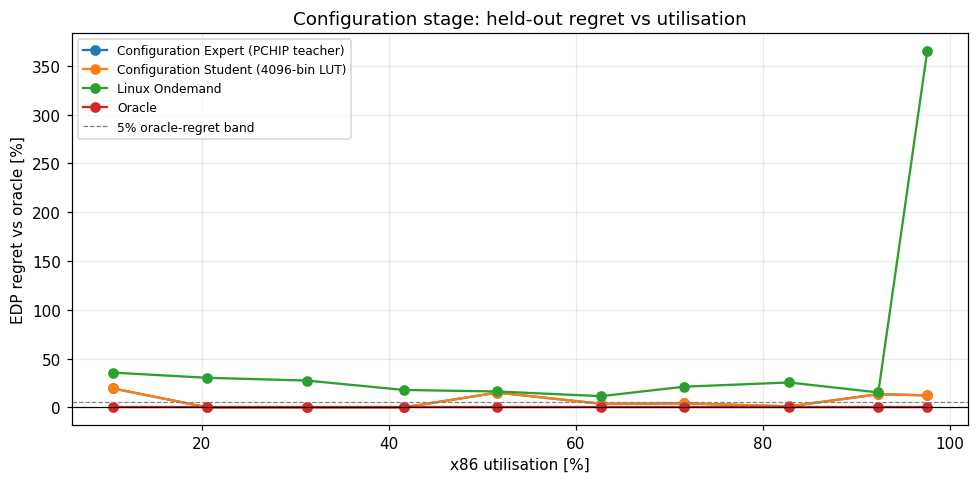

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for policy, g in CONFIG_LOOCV.groupby("policy"):
    g = g.sort_values("rho")
    ax.plot(100 * g["rho"], 100 * g["regret"], marker="o", label=policy)
ax.axhline(0, color="black", lw=0.8)
ax.axhline(5, color="gray", ls="--", lw=0.8, label="5% oracle-regret band")
ax.set_xlabel("x86 utilisation [%]")
ax.set_ylabel("EDP regret vs oracle [%]")
ax.set_title("Configuration stage: held-out regret vs utilisation")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "01_configuration_regret.png", dpi=150)
plt.show()

## 5. Frequency model — RBF-SVR teacher + MLP student

Frequency was **observed**, never independently commanded — so this model predicts the frequency
*associated with* a state and a chosen configuration, not a counterfactual. The teacher is a fixed
RBF-SVR (`C=100, gamma=0.1`, run to full convergence rather than capped) predicting normalised
frequency, clipped to `[0, 1]` and denormalised into the architecture's legal range — legal by
construction. The student is a small 32×32 MLP (plain NumPy, Adam optimiser) distilled from the
teacher on a dense grid spanning utilisation × all 50 configurations × both architectures.

The same `MLP` class is reused for every RL network later in the notebook, which is why it also
carries a `copy()` and `soft_update_from()` (needed for target networks) even though the frequency
student itself doesn't use them.


In [ ]:
class MLP:
    """Minimal fully-connected network: manual forward/backward, Adam, input gradients, and a
    soft target-network update. Implemented in plain NumPy so the notebook needs no deep
    learning framework and is fully deterministic given a seed."""

    def __init__(self, sizes: Sequence[int], out_act: str = "linear", seed: int = 0,
                 lr: float = 3e-3, hidden_act: str = "tanh"):
        rng = np.random.default_rng(seed)
        self.sizes, self.out_act, self.hidden_act, self.lr = list(sizes), out_act, hidden_act, lr
        self.W = [rng.normal(0, np.sqrt(1.0 / a), (a, b)) for a, b in zip(self.sizes[:-1], self.sizes[1:])]
        self.b = [np.zeros(b) for b in self.sizes[1:]]
        self._acts = None
        self._reset_adam()

    def _reset_adam(self):
        self.mW = [np.zeros_like(w) for w in self.W]; self.vW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(b) for b in self.b]; self.vb = [np.zeros_like(b) for b in self.b]
        self.t = 0

    def forward(self, X: np.ndarray, cache: bool = False):
        A = np.asarray(X, dtype=float)
        acts = [A]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b
            if i < len(self.W) - 1:
                A = np.tanh(Z)
            elif self.out_act == "sigmoid":
                A = 1.0 / (1.0 + np.exp(-np.clip(Z, -30, 30)))
            elif self.out_act == "tanh":
                A = np.tanh(Z)
            else:
                A = Z
            acts.append(A)
        if cache:
            self._acts = acts
        return A

    __call__ = forward

    def backward(self, dY: np.ndarray):
        """Given dLoss/dOutput, return (dW, db, dLoss/dInput)."""
        acts = self._acts
        dW = [None] * len(self.W); db = [None] * len(self.b)
        Y = acts[-1]
        if self.out_act == "sigmoid":
            dZ = dY * (Y * (1.0 - Y))
        elif self.out_act == "tanh":
            dZ = dY * (1.0 - Y ** 2)
        else:
            dZ = dY
        for i in range(len(self.W) - 1, -1, -1):
            dW[i] = acts[i].T @ dZ
            db[i] = dZ.sum(axis=0)
            dA = dZ @ self.W[i].T
            dZ = dA * (1.0 - acts[i] ** 2) if i > 0 else dA
        return dW, db, dZ

    def adam_step(self, dW, db, lr: float = None, b1=0.9, b2=0.999, eps=1e-8):
        lr = self.lr if lr is None else lr
        if not self.mW:
            self._reset_adam()
        self.t += 1
        for i in range(len(self.W)):
            self.mW[i] = b1 * self.mW[i] + (1 - b1) * dW[i]
            self.vW[i] = b2 * self.vW[i] + (1 - b2) * dW[i] ** 2
            self.mb[i] = b1 * self.mb[i] + (1 - b1) * db[i]
            self.vb[i] = b2 * self.vb[i] + (1 - b2) * db[i] ** 2
            mW = self.mW[i] / (1 - b1 ** self.t); vW = self.vW[i] / (1 - b2 ** self.t)
            mb = self.mb[i] / (1 - b1 ** self.t); vb = self.vb[i] / (1 - b2 ** self.t)
            self.W[i] -= lr * mW / (np.sqrt(vW) + eps)
            self.b[i] -= lr * mb / (np.sqrt(vb) + eps)

    def fit_regression(self, X, Y, epochs: int = 500, batch: int = 256, lr: float = None, seed: int = 0) -> "MLP":
        rng = np.random.default_rng(seed)
        X = np.asarray(X, dtype=float); Y = np.asarray(Y, dtype=float).reshape(len(X), -1)
        n = len(X)
        for _ in range(epochs):
            order = rng.permutation(n)
            for s in range(0, n, batch):
                sl = order[s:s + batch]
                pred = self.forward(X[sl], cache=True)
                dW, db, _ = self.backward(2.0 * (pred - Y[sl]) / len(sl))
                self.adam_step(dW, db, lr)
        return self

    def strip_state(self) -> "MLP":
        """Drop optimiser state + cached activations before serialising a deployment artifact."""
        self.mW, self.vW, self.mb, self.vb, self.t = [], [], [], [], 0
        self._acts = None
        return self

    def copy(self) -> "MLP":
        other = MLP(self.sizes, self.out_act, 0, self.lr, self.hidden_act)
        other.W = [w.copy() for w in self.W]; other.b = [b.copy() for b in self.b]
        return other

    def soft_update_from(self, src: "MLP", tau: float):
        for i in range(len(self.W)):
            self.W[i] = (1 - tau) * self.W[i] + tau * src.W[i]
            self.b[i] = (1 - tau) * self.b[i] + tau * src.b[i]

    @property
    def n_params(self) -> int:
        return int(sum(w.size for w in self.W) + sum(b.size for b in self.b))

In [ ]:
class FrequencyExpert:
    """Architecture-aware RBF-SVR frequency model. Predicts normalised frequency, clipped to
    [0, 1], then denormalised into the architecture's authoritative legal range."""

    def __init__(self, cfg: CFG = CFG_):
        self.cfg = cfg
        self.model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=cfg.freq_expert_C, gamma=cfg.freq_expert_gamma,
                        epsilon=cfg.freq_expert_epsilon, tol=cfg.freq_expert_tol,
                        cache_size=500, max_iter=cfg.freq_expert_max_iter)),
        ])

    def fit(self, train: pd.DataFrame) -> "FrequencyExpert":
        self.model.fit(train[FEATURES_FREQ].to_numpy(), train["f_norm"].to_numpy())
        self.train_states_ = sorted(train["state_id"].unique())
        self.rho_bounds_ = {a: (float(g["rho"].min()), float(g["rho"].max())) for a, g in train.groupby("platform")}
        return self

    def predict_norm(self, rho, sr_norm_v, thr_norm_v, architecture: str, min_frequency: float, max_frequency: float) -> np.ndarray:
        X = freq_features(rho, sr_norm_v, thr_norm_v, architecture, min_frequency, max_frequency)
        return np.clip(np.asarray(self.model.predict(X), dtype=float), 0.0, 1.0)

    def predict(self, utilization, sampling_rate_us, threshold_pct, architecture: str,
                min_frequency: float = None, max_frequency: float = None) -> np.ndarray:
        lo, hi = FREQ_LIMITS[architecture]
        lo = lo if min_frequency is None else float(min_frequency)
        hi = hi if max_frequency is None else float(max_frequency)
        sr = np.atleast_1d(np.asarray(sampling_rate_us, dtype=float))
        thr = np.atleast_1d(np.asarray(threshold_pct, dtype=float))
        srn = (sr - SR_ARR.min()) / max(1, SR_ARR.max() - SR_ARR.min())
        thn = (thr - THR_ARR.min()) / max(1, THR_ARR.max() - THR_ARR.min())
        pred_norm = self.predict_norm(utilization, srn, thn, architecture, lo, hi)
        return lo + pred_norm * (hi - lo)

    def predict_grid(self, utilization: float, architecture: str) -> np.ndarray:
        lo, hi = FREQ_LIMITS[architecture]
        pred_norm = self.predict_norm(np.full(N_ACTIONS, utilization), SRN_ARR, THRN_ARR, architecture, lo, hi)
        return lo + pred_norm * (hi - lo)


def distillation_grid(rho_bounds: Dict[str, Tuple[float, float]], cfg: CFG = CFG_) -> np.ndarray:
    Xs = []
    for arch in ARCHS:
        rho_lo, rho_hi = rho_bounds[arch]
        rho_grid = np.linspace(rho_lo, rho_hi, cfg.freq_distill_rho_points)
        lo, hi = FREQ_LIMITS[arch]
        rho_rep = np.repeat(rho_grid, N_ACTIONS)
        srn = np.tile(SRN_ARR, len(rho_grid)); thn = np.tile(THRN_ARR, len(rho_grid))
        Xs.append(freq_features(rho_rep, srn, thn, arch, lo, hi))
    return np.vstack(Xs)


class FrequencyStudent:
    """Compact MLP distilled from a FrequencyExpert on a dense (utilisation x configuration x
    architecture) grid. Sigmoid output => legal frequency by construction."""

    def __init__(self, hidden: Sequence[int] = None, cfg: CFG = CFG_, seed: int = None):
        self.cfg = cfg
        self.hidden = tuple(hidden or cfg.freq_student_hidden)
        self.seed = cfg.seed if seed is None else seed
        self.net = MLP([len(FEATURES_FREQ), *self.hidden, 1], out_act="sigmoid", seed=self.seed, lr=cfg.freq_student_lr)

    def distill(self, teacher: FrequencyExpert, rho_bounds: Dict[str, Tuple[float, float]] = None, epochs: int = None) -> "FrequencyStudent":
        rho_bounds = rho_bounds or teacher.rho_bounds_
        X = distillation_grid(rho_bounds, self.cfg)
        y = np.clip(teacher.model.predict(X), 0.0, 1.0).reshape(-1, 1)
        self.n_distill_samples_ = int(len(X))
        self.net.fit_regression(X, y, epochs=int(epochs or self.cfg.freq_student_epochs), batch=512, seed=self.seed)
        self.train_states_ = list(getattr(teacher, "train_states_", []))
        return self

    def predict_norm(self, rho, sr_norm_v, thr_norm_v, architecture: str, min_frequency: float, max_frequency: float) -> np.ndarray:
        X = freq_features(rho, sr_norm_v, thr_norm_v, architecture, min_frequency, max_frequency)
        return np.clip(self.net.forward(X).ravel(), 0.0, 1.0)

    def predict(self, utilization, sampling_rate_us, threshold_pct, architecture: str,
                min_frequency: float = None, max_frequency: float = None) -> np.ndarray:
        lo, hi = FREQ_LIMITS[architecture]
        lo = lo if min_frequency is None else float(min_frequency)
        hi = hi if max_frequency is None else float(max_frequency)
        sr = np.atleast_1d(np.asarray(sampling_rate_us, dtype=float))
        thr = np.atleast_1d(np.asarray(threshold_pct, dtype=float))
        srn = (sr - SR_ARR.min()) / max(1, SR_ARR.max() - SR_ARR.min())
        thn = (thr - THR_ARR.min()) / max(1, THR_ARR.max() - THR_ARR.min())
        pred_norm = self.predict_norm(utilization, srn, thn, architecture, lo, hi)
        return lo + pred_norm * (hi - lo)

    def predict_grid(self, utilization: float, architecture: str) -> np.ndarray:
        lo, hi = FREQ_LIMITS[architecture]
        pred_norm = self.predict_norm(np.full(N_ACTIONS, utilization), SRN_ARR, THRN_ARR, architecture, lo, hi)
        return lo + pred_norm * (hi - lo)

    @property
    def n_params(self) -> int:
        return self.net.n_params


print("Stage 3 classes (frequency expert + student + MLP) defined.")

Stage 3 classes (frequency expert + student + MLP) defined.


## 6. Frequency evaluation

Leave-one-`(architecture, utilisation)`-state-out over all 20 states (10 x86 + 10 ARM). Alongside
the usual MAE/RMSE/R²/MAPE, two extra checks:

- **Solver convergence audit** — the RBF-SVR must actually converge in every fold (an uncapped
  iteration budget is used specifically so this can't silently fail).
- **Config-blind-oracle skill check** — how much does knowing the *configuration* actually help,
  versus just predicting each state's own average frequency? On x86 the configuration barely moves
  frequency at all (a few MHz), so don't be surprised if the "blind" baseline wins there; on ARM the
  configuration matters a lot more.


In [ ]:
FREQ_FOLD_ASSETS: Dict[str, Dict[str, object]] = {}
freq_rows = []
convergence_hits = 0
for i, sid in enumerate(ANALYSIS_STATE_IDS, 1):
    state = STATE_ROW.loc[sid]
    arch, rho = state["platform"], float(state["rho"])
    train_rows = FREQ_TABLE[FREQ_TABLE.state_id != sid]
    assert sid not in set(train_rows.state_id)

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        teacher = FrequencyExpert().fit(train_rows)
    convergence_hits += any(issubclass(w.category, ConvergenceWarning) for w in caught)
    student = FrequencyStudent(CFG_.freq_student_hidden).distill(teacher)
    FREQ_FOLD_ASSETS[sid] = {"expert": teacher, "student": student}

    heldout = FREQ_TABLE[FREQ_TABLE.state_id == sid].sort_values("config_id").reset_index(drop=True)
    assert len(heldout) == N_ACTIONS
    teacher_pred = teacher.predict_grid(rho, arch)
    student_pred = student.predict_grid(rho, arch)
    lo, hi = FREQ_LIMITS[arch]
    for k, r in heldout.iterrows():
        freq_rows.append(dict(state_id=sid, platform=arch, rho=rho, config_id=int(r.config_id),
                               measured_khz=float(r.freq_khz), teacher_khz=float(teacher_pred[k]),
                               student_khz=float(student_pred[k]), fmin=lo, fmax=hi))
    print(f"  frequency fold {i}/{len(ANALYSIS_STATE_IDS)}: {sid} done", flush=True)

FREQ_LOOCV = pd.DataFrame(freq_rows)
assert convergence_hits == 0, "the SVR teacher failed to converge in at least one fold"
print(f"\nSolver convergence audit: 0/{len(ANALYSIS_STATE_IDS)} folds hit the iteration cap. Good.")


def frequency_metrics(df: pd.DataFrame, pred_col: str, name: str, teacher_col: str = "teacher_khz") -> Dict[str, float]:
    pred, meas = df[pred_col].to_numpy(), df["measured_khz"].to_numpy()
    span = (df["fmax"] - df["fmin"]).to_numpy()
    out = {
        "model": name,
        "mae_mhz": float(np.mean(np.abs(pred - meas)) / 1e3),
        "rmse_mhz": float(np.sqrt(np.mean((pred - meas) ** 2)) / 1e3),
        "r2": float(r2_score(meas, pred)),
        "mape_%": float(100 * np.mean(np.abs(pred - meas) / meas)),
        "normalised_mae_%_of_span": float(100 * np.mean(np.abs(pred - meas) / span)),
        "worst_state_mae_mhz": float(df.assign(err=np.abs(pred - meas)).groupby("state_id")["err"].mean().max() / 1e3),
        "legal_violation_%": float(100 * np.mean((pred < df["fmin"].to_numpy() - 1e-6) | (pred > df["fmax"].to_numpy() + 1e-6))),
    }
    if pred_col != teacher_col:
        d = np.abs(pred - df[teacher_col].to_numpy())
        out["mae_vs_teacher_mhz"] = float(np.mean(d) / 1e3)
    else:
        out["mae_vs_teacher_mhz"] = 0.0
    return out


FREQ_EXPERT_NAME = "Frequency Expert (RBF-SVR)"
FREQ_STUDENT_NAME = f"Frequency Student (MLP {'x'.join(map(str, CFG_.freq_student_hidden))})"
FREQ_SUMMARY = pd.DataFrame([
    frequency_metrics(FREQ_LOOCV, "teacher_khz", FREQ_EXPERT_NAME),
    frequency_metrics(FREQ_LOOCV, "student_khz", FREQ_STUDENT_NAME),
])
print("\nFrequency policies, leave-one-state-out, both architectures:")
print(FREQ_SUMMARY.to_string(index=False))
assert (FREQ_SUMMARY["legal_violation_%"] == 0).all()

# Config-blind oracle: predict each held-out state's OWN mean measured frequency, ignoring the
# configuration entirely. A model that cannot beat this has learned nothing from (SR, threshold).
blind_pred = FREQ_LOOCV.groupby("state_id")["measured_khz"].transform("mean")
FREQ_LOOCV = FREQ_LOOCV.assign(blind_khz=blind_pred)
skill_rows = []
for platform, g in FREQ_LOOCV.groupby("platform"):
    mae = lambda c: float(np.abs(g[c] - g["measured_khz"]).mean() / 1e3)
    skill_rows.append({"platform": platform, "student_mae_mhz": mae("student_khz"),
                        "config_blind_oracle_mae_mhz": mae("blind_khz"),
                        "student_skill_ratio (<1 means the configuration helps)": mae("student_khz") / mae("blind_khz")})
PLATFORM_SKILL = pd.DataFrame(skill_rows)
print("\nDoes the frequency student actually use the configuration, per architecture?")
print(PLATFORM_SKILL.to_string(index=False))

  frequency fold 1/20: ARM@10 done


  frequency fold 2/20: ARM@20 done


  frequency fold 3/20: ARM@30 done


  frequency fold 4/20: ARM@40 done


  frequency fold 5/20: ARM@50 done


...

  frequency fold 17/20: x86@70 done


  frequency fold 18/20: x86@80 done


  frequency fold 19/20: x86@90 done


  frequency fold 20/20: x86@100 done



Solver convergence audit: 0/20 folds hit the iteration cap. Good.

Frequency policies, leave-one-state-out, both architectures:
                        model  mae_mhz  rmse_mhz     r2  mape_%  normalised_mae_%_of_span  worst_state_mae_mhz  legal_violation_%  mae_vs_teacher_mhz
   Frequency Expert (RBF-SVR)  29.9143   59.4685 0.9253  1.5328                    2.1228             227.9725             0.0000              0.0000
Frequency Student (MLP 32x32)  16.8509   29.2289 0.9820  0.9050                    1.1159              80.6672             0.0000             18.5770

Does the frequency student actually use the configuration, per architecture?
platform  student_mae_mhz  config_blind_oracle_mae_mhz  student_skill_ratio (<1 means the configuration helps)
     ARM          16.8748                      72.3291                                                  0.2333
     x86          16.8270                       8.7148                                                  1.9309


In [ ]:
DEPLOY_FREQ_EXPERT = FrequencyExpert().fit(FREQ_TABLE)
DEPLOY_FREQ_STUDENT = FrequencyStudent(CFG_.freq_student_hidden).distill(DEPLOY_FREQ_EXPERT)
DEPLOY_FREQ_STUDENT.net.strip_state()

demo_arch = "x86"
demo_sr, demo_thr = int(SR_ARR[len(SR_ARR) // 2]), int(THR_ARR[len(THR_ARR) // 2])
FREQ_LATENCY = pd.DataFrame([
    dict(model=FREQ_EXPERT_NAME,
         **dict(zip(("median_ms", "p95_ms", "p99_ms"), bench(lambda: DEPLOY_FREQ_EXPERT.predict(DEMO_RHO, demo_sr, demo_thr, demo_arch)))),
         size_kb=size_kb(DEPLOY_FREQ_EXPERT, "freq_expert")),
    dict(model=FREQ_STUDENT_NAME,
         **dict(zip(("median_ms", "p95_ms", "p99_ms"), bench(lambda: DEPLOY_FREQ_STUDENT.predict(DEMO_RHO, demo_sr, demo_thr, demo_arch)))),
         size_kb=size_kb(DEPLOY_FREQ_STUDENT, "freq_student")),
])
FREQ_LATENCY["speedup_vs_expert"] = FREQ_LATENCY.loc[0, "median_ms"] / FREQ_LATENCY["median_ms"]
print("\nFrequency model latency (single prediction):")
print(FREQ_LATENCY.to_string(index=False))

print("Stage 3 (frequency expert + student) complete.")


Frequency model latency (single prediction):
                        model  median_ms  p95_ms  p99_ms  size_kb  speedup_vs_expert
   Frequency Expert (RBF-SVR)     0.2549  0.3667  0.4787  28.5020             1.0000
Frequency Student (MLP 32x32)     0.0503  0.0798  0.0933  13.0195             5.0627
Stage 3 (frequency expert + student) complete.


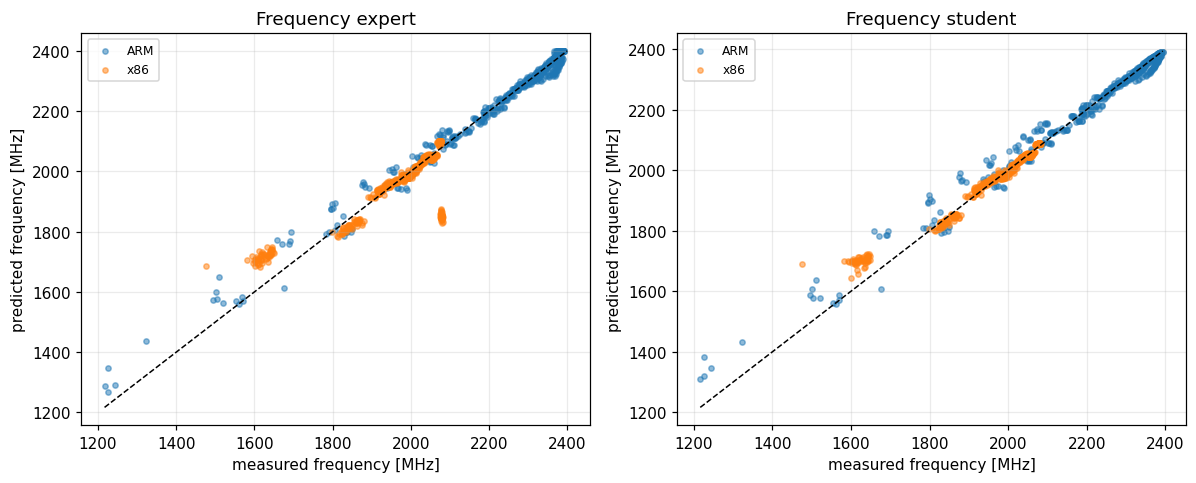

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, title in [(axes[0], "teacher_khz", "Frequency expert"), (axes[1], "student_khz", "Frequency student")]:
    for arch, g in FREQ_LOOCV.groupby("platform"):
        ax.scatter(g["measured_khz"] / 1e3, g[col] / 1e3, s=12, alpha=0.5, label=arch)
    lo = FREQ_LOOCV[["measured_khz", col]].min().min() / 1e3
    hi = FREQ_LOOCV[["measured_khz", col]].max().max() / 1e3
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("measured frequency [MHz]")
    ax.set_ylabel("predicted frequency [MHz]")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "02_frequency_fit.png", dpi=150)
plt.show()

## 7. Final Expert = Configuration Student → Frequency Student

The deployed controller: `rho` goes into the **configuration student**, its chosen `(sampling rate,
threshold)` — together with `rho` and the architecture — goes into the **frequency student**, which
predicts the frequency. Composed entirely of the two *distilled students*, per the brief.

Because EDP is a property of the measured `(SR, threshold)` alone, attaching the frequency stage
cannot change the configuration decision or its EDP regret — the cell below asserts exactly that,
then reports the pipeline's own frequency accuracy and its end-to-end latency (both models chained).


In [ ]:
class FinalExpertPipeline:
    """The deployed controller: rho -> configuration student -> (SR, threshold) -> that
    decision is fed into the frequency student (together with rho and the architecture) ->
    predicted operating frequency. Composed entirely of the two DISTILLED STUDENTS."""

    def __init__(self, config_model, freq_model, architecture: str = "x86"):
        self.config_model = config_model
        self.freq_model = freq_model
        self.architecture = architecture

    def predict(self, rho: float) -> Dict[str, object]:
        cfg_out = self.config_model.predict(rho)
        cid = int(cfg_out["config_id"])
        freq_khz = float(np.atleast_1d(self.freq_model.predict(
            rho, cfg_out["sampling_rate_us"], cfg_out["threshold_pct"], self.architecture))[0])
        return {"config_id": cid, "sampling_rate_us": cfg_out["sampling_rate_us"],
                "threshold_pct": cfg_out["threshold_pct"], "frequency_khz": freq_khz,
                "architecture": self.architecture}


pipeline_rows = []
for sid in X86_STATE_IDS:
    rho = float(STATE_ROW.loc[sid, "rho"])
    config_student = CONFIG_FOLD_ASSETS[sid]["student"]          # trained without this state
    freq_student = FREQ_FOLD_ASSETS[sid]["student"]               # trained without this state
    pipe = FinalExpertPipeline(config_student, freq_student, "x86")
    out = pipe.predict(rho)

    # the pipeline must not change the (SR, threshold) decision vs the standalone student
    assert out["config_id"] == int(config_student.predict_config(rho)[0])

    measured_khz = float(FREQ_TABLE[(FREQ_TABLE.state_id == sid) & (FREQ_TABLE.config_id == out["config_id"])]["freq_khz"].iloc[0])
    row = STATE_ROW.loc[sid]
    edp = float(EDP_MATRIX.loc[sid, out["config_id"]])
    pipeline_rows.append(dict(state_id=sid, rho=rho, config_id=out["config_id"],
                               sampling_rate_us=out["sampling_rate_us"], threshold_pct=out["threshold_pct"],
                               regret=edp / row.edp_oracle - 1.0, delta_vs_ondemand=edp / row.edp_ondemand - 1.0,
                               predicted_freq_khz=out["frequency_khz"], measured_freq_khz=measured_khz,
                               freq_abs_err_khz=abs(out["frequency_khz"] - measured_khz)))

PIPELINE_LOOCV = pd.DataFrame(pipeline_rows)
PIPELINE_CONFIG_METRICS = config_policy_metrics(PIPELINE_LOOCV.assign(oracle_config_id=X86_STATES.set_index("state_id").loc[PIPELINE_LOOCV.state_id, "oracle_config_id"].to_numpy()))
PIPELINE_FREQ_MAE_MHZ = float(PIPELINE_LOOCV["freq_abs_err_khz"].mean() / 1e3)
print("Final Expert Pipeline (Configuration Student -> Frequency Student), held-out x86 states:")
print(PIPELINE_LOOCV[["state_id", "rho", "sampling_rate_us", "threshold_pct", "regret", "predicted_freq_khz", "measured_freq_khz"]].to_string(index=False))
print(f"\nPipeline EDP regret: mean={PIPELINE_CONFIG_METRICS['mean_regret']:.4f} "
      f"(identical to the standalone configuration student - attaching frequency prediction "
      f"cannot change the configuration decision)")
print(f"Pipeline frequency MAE on the configuration it actually selected: {PIPELINE_FREQ_MAE_MHZ:.2f} MHz")
assert abs(PIPELINE_CONFIG_METRICS["mean_regret"] - CONFIG_SUMMARY.set_index("policy").loc[f"Configuration Student ({CFG_.lut_bins}-bin LUT)", "mean_regret"]) < 1e-9

# ---- deploy pipeline (full-data students) + end-to-end latency ----
DEPLOY_PIPELINE = FinalExpertPipeline(DEPLOY_CONFIG_STUDENT, DEPLOY_FREQ_STUDENT, "x86")
print("\nExample pipeline decision at rho=0.63:", DEPLOY_PIPELINE.predict(0.63))

PIPELINE_LATENCY = pd.DataFrame([dict(
    model="Final Expert Pipeline (Configuration Student -> Frequency Student)",
    **dict(zip(("median_ms", "p95_ms", "p99_ms"), bench(lambda: DEPLOY_PIPELINE.predict(DEMO_RHO)))),
    size_kb=size_kb((DEPLOY_CONFIG_STUDENT, DEPLOY_FREQ_STUDENT), "pipeline_students"),
)])
print("\nPipeline end-to-end latency (single decision):")
print(PIPELINE_LATENCY.to_string(index=False))

print("Stage 4 (final expert pipeline) complete.")

Final Expert Pipeline (Configuration Student -> Frequency Student), held-out x86 states:
state_id    rho  sampling_rate_us  threshold_pct  regret  predicted_freq_khz  measured_freq_khz
  x86@10 0.1047             80000             90  0.1952      1,701,219.0585     1,603,740.0000
  x86@20 0.2060             10000             75  0.0000      1,806,082.2462     1,824,630.0000
  x86@30 0.3122             10000             75  0.0000      1,938,464.4051     1,921,505.0000
  x86@40 0.4162             10000             75  0.0000      1,978,579.6280     1,966,860.0000
  x86@50 0.5160             10000             75  0.1514      1,991,110.5571     1,998,135.0000
  x86@60 0.6269             90000             95  0.0369      2,011,996.8098     2,014,085.0000
  x86@70 0.7159             80000             75  0.0410      2,040,893.2384     2,035,415.0000
  x86@80 0.8278            100000             75  0.0103      2,048,411.4351     2,053,795.0000
  x86@90 0.9231             70000             8

## 8. Offline reinforcement learning — what this data can and cannot support

The measurements are a **full-information contextual bandit**: every one of the 50 configurations
was measured in every state. There is no `(state, action, reward, next_state)` trajectory. So:

- every agent below uses **`gamma = 0`** — this is offline policy *warming*, not sequential control;
- the reward for a configuration is the fold-local configuration expert's (z-normalised) score —
  never the held-out EDP itself;
- frequency was never independently commanded, so it can **only** enter RL as an *imitation* signal
  towards the frequency expert's prediction — never as a fabricated EDP reward for a frequency.

Each outer fold builds a dense synthetic reward surface from that fold's own configuration + frequency
experts (the same fold-local models already fit during sections 4 and 6 above), so nothing about the
held-out state leaks in before an agent commits to an action.


In [ ]:
# The measurements are a full-information contextual bandit (all 50 configurations measured in
# every state), not a trajectory dataset. Every agent below therefore uses gamma = 0. Frequency
# was observed, never independently commanded, so it can only enter RL as an imitation signal
# towards the frequency expert - never as a fabricated EDP reward.
@dataclass
class FoldRL:
    """Everything an agent may see inside one training fold."""
    state_id: str
    arch: str
    mu: np.ndarray
    sd: np.ndarray
    S: np.ndarray            # (G, 2) standardised synthetic states
    rho_grid: np.ndarray     # (G,)
    Q: np.ndarray            # (G, N_ACTIONS) z-normalised configuration reward (higher is better)
    Fnorm: np.ndarray        # (G, N_ACTIONS) frequency-expert normalised frequency targets
    best_config: np.ndarray  # (G,) teacher arg-max configuration

    def encode(self, rho: float) -> np.ndarray:
        x = np.array([[float(rho), np.log10(max(1.0 - float(rho), CFG_.rho_eps))]])
        return (x - self.mu) / self.sd


def make_fold_rl(config_expert, freq_expert, rho_min: float, rho_max: float, arch: str = "x86",
                  state_id: str = "fold", cfg: CFG = CFG_) -> FoldRL:
    """Dense synthetic reward surface built from a pair of fold-local experts."""
    rho_grid = np.linspace(rho_min, rho_max, cfg.rl_grid_points)
    raw = np.column_stack([rho_grid, np.log10(np.clip(1.0 - rho_grid, cfg.rho_eps, None))])
    mu, sd = raw.mean(0, keepdims=True), raw.std(0, keepdims=True) + 1e-9
    Q = -config_expert.score(rho_grid)                     # PCHIP score = predicted delta-log-EDP (lower better)
    Q = (Q - Q.mean()) / (Q.std() + 1e-9)
    lo, hi = FREQ_LIMITS[arch]
    Fnorm = np.vstack([freq_expert.predict_norm(np.full(N_ACTIONS, r), SRN_ARR, THRN_ARR, arch, lo, hi)
                        for r in rho_grid])
    return FoldRL(state_id, arch, mu, sd, (raw - mu) / sd, rho_grid, Q, Fnorm, np.argmax(Q, axis=1))


def build_fold_rl(sid: str, cfg: CFG = CFG_) -> FoldRL:
    """Reuse the already-fitted fold-local configuration + frequency experts for x86 state `sid`."""
    assets = CONFIG_FOLD_ASSETS[sid]
    return make_fold_rl(assets["expert"], FREQ_FOLD_ASSETS[sid]["expert"],
                         assets["rho_min"], assets["rho_max"], "x86", sid, cfg)


def frequency_bin_centers(arch: str, n_bins: int, cfg: CFG = CFG_) -> np.ndarray:
    """Uniform legal frequency bins spanning [f_min, f_max]; bins can never leave the legal range."""
    lo, hi = FREQ_LIMITS[arch]
    edges = np.linspace(lo, hi, n_bins + 1)
    return 0.5 * (edges[:-1] + edges[1:])


def grouped_state_splits(state_ids: Sequence[str], k: int) -> List[Tuple[List[str], List[str]]]:
    """Deterministic grouped splits: sort by (platform, rho), then round-robin into k folds."""
    ordered = sorted(state_ids, key=lambda s: (STATE_ROW.loc[s, "platform"], STATE_ROW.loc[s, "rho"]))
    k = int(max(2, min(k, len(ordered))))
    folds = [ordered[i::k] for i in range(k)]
    return [([s for j, f in enumerate(folds) if j != i for s in f], folds[i]) for i in range(k) if folds[i]]


print("Stage 5a (RL reward-surface machinery) defined.")

Stage 5a (RL reward-surface machinery) defined.


## 9. Discrete RL — DDQN and Dueling DDQN

The true action space *is* discrete (50 configurations), so this is the primary RL experiment. Both
agents emit 50 Q-values and act greedily; Double-DQN target computation and a soft-updated target
network are used even though `gamma=0` makes the bootstrap term vanish (kept for generality).

- **DDQN**: `state → 48 tanh → 48 tanh → 50 Q-values`
- **Dueling DDQN**: shared 48-unit trunk, a value head and an advantage head, `Q = V + A - mean(A)`


In [ ]:
class QNet:
    """Plain Q-network over the 50 discrete configurations: state -> 48 tanh -> 48 tanh -> 50 Q."""

    def __init__(self, in_dim: int, n_actions: int, hidden: Sequence[int], seed: int, lr: float):
        self.net = MLP([in_dim, *hidden, n_actions], out_act="linear", seed=seed, lr=lr)

    def q(self, S: np.ndarray, cache: bool = False) -> np.ndarray:
        return self.net.forward(S, cache=cache)

    def grad_step(self, S: np.ndarray, a: np.ndarray, y: np.ndarray):
        P = self.q(S, cache=True)
        dY = np.zeros_like(P)
        dY[np.arange(len(S)), a] = 2.0 * (P[np.arange(len(S)), a] - y) / len(S)
        dW, db, _ = self.net.backward(dY)
        self.net.adam_step(dW, db)

    def copy(self) -> "QNet":
        other = QNet.__new__(QNet); other.net = self.net.copy(); return other

    def soft_update_from(self, src: "QNet", tau: float):
        self.net.soft_update_from(src.net, tau)

    @property
    def n_params(self) -> int:
        return self.net.n_params


class DuelingQNet(QNet):
    """Shared trunk, scalar value head, per-action advantage head: Q = V + A - mean(A)."""

    def __init__(self, in_dim: int, n_actions: int, hidden: Sequence[int], seed: int, lr: float):
        h = hidden[0]
        self.trunk = MLP([in_dim, h], out_act="tanh", seed=seed, lr=lr)
        self.vhead = MLP([h, 1], out_act="linear", seed=seed + 1, lr=lr)
        self.ahead = MLP([h, n_actions], out_act="linear", seed=seed + 2, lr=lr)

    def q(self, S: np.ndarray, cache: bool = False) -> np.ndarray:
        H = self.trunk.forward(S, cache=cache)
        V = self.vhead.forward(H, cache=cache)
        A = self.ahead.forward(H, cache=cache)
        return V + A - A.mean(axis=1, keepdims=True)

    def grad_step(self, S: np.ndarray, a: np.ndarray, y: np.ndarray):
        Q = self.q(S, cache=True)
        dQ = np.zeros_like(Q)
        dQ[np.arange(len(S)), a] = 2.0 * (Q[np.arange(len(S)), a] - y) / len(S)
        dWv, dbv, dHv = self.vhead.backward(dQ.sum(axis=1, keepdims=True))
        dWa, dba, dHa = self.ahead.backward(dQ - dQ.mean(axis=1, keepdims=True))
        dWt, dbt, _ = self.trunk.backward(dHv + dHa)
        self.vhead.adam_step(dWv, dbv); self.ahead.adam_step(dWa, dba); self.trunk.adam_step(dWt, dbt)

    def copy(self) -> "DuelingQNet":
        other = DuelingQNet.__new__(DuelingQNet)
        other.trunk, other.vhead, other.ahead = self.trunk.copy(), self.vhead.copy(), self.ahead.copy()
        return other

    def soft_update_from(self, src: "DuelingQNet", tau: float):
        self.trunk.soft_update_from(src.trunk, tau)
        self.vhead.soft_update_from(src.vhead, tau)
        self.ahead.soft_update_from(src.ahead, tau)

    @property
    def n_params(self) -> int:
        return self.trunk.n_params + self.vhead.n_params + self.ahead.n_params


def train_ddqn(fold: FoldRL, seed: int, dueling: bool = False, reward: np.ndarray = None, cfg: CFG = CFG_) -> QNet:
    """Offline Double-DQN warm start on the fold-local reward surface (gamma = 0)."""
    rng = np.random.default_rng(seed)
    R = fold.Q if reward is None else reward
    G, A = R.shape
    cls = DuelingQNet if dueling else QNet
    online = cls(fold.S.shape[1], A, cfg.rl_hidden, seed, cfg.rl_lr)
    target = online.copy()
    for step in range(cfg.rl_steps):
        eps = cfg.rl_eps_end + (cfg.rl_eps_start - cfg.rl_eps_end) * (1 - step / max(1, cfg.rl_steps))
        gi = rng.integers(0, G, cfg.rl_batch)
        S = fold.S[gi]
        greedy = np.argmax(online.q(S), axis=1)
        explore = rng.random(cfg.rl_batch) < eps
        a = np.where(explore, rng.integers(0, A, cfg.rl_batch), greedy)
        r = R[gi, a]
        # Double DQN target: online net selects, target net evaluates. gamma=0 => the bootstrap
        # term is exactly zero here; kept in the formula so the code generalises to sequential data.
        a_next = np.argmax(online.q(S), axis=1)
        q_next = target.q(S)[np.arange(cfg.rl_batch), a_next]
        y = r + cfg.gamma * q_next
        online.grad_step(S, a, y)
        target.soft_update_from(online, cfg.rl_target_tau)
    return online


print("Stage 5b (DDQN, Dueling DDQN) defined.")

Stage 5b (DDQN, Dueling DDQN) defined.


## 10. Discretised-frequency DDQN — DDQN with a **binned** frequency head

This is the DDQN variant that predicts frequency: a **factorised** network — shared trunk,
configuration head (50 actions), and a configuration-conditioned frequency head over a small set of
frequency **bins** (never a continuous value). The configuration head is trained on the EDP reward
plus `lambda_freq × (best achievable frequency-imitation reward)`; the frequency head is trained on
`-distance²` to the frequency expert's target for the bin actually chosen. Bin count and
`lambda_freq` are tuned per outer fold in section 12.


In [ ]:
class FactorisedQNet:
    """Shared trunk + configuration Q head (50 actions) + configuration-conditioned frequency Q
    head (n_bins). This is the DDQN variant that explicitly chooses a discrete frequency bin."""

    def __init__(self, in_dim: int, n_actions: int, n_bins: int, hidden: Sequence[int], seed: int, lr: float):
        h = hidden[0]
        self.trunk = MLP([in_dim, h], out_act="tanh", seed=seed, lr=lr)
        self.chead = MLP([h, *hidden[1:], n_actions], out_act="linear", seed=seed + 1, lr=lr)
        self.fhead = MLP([h + 2, *hidden[1:], n_bins], out_act="linear", seed=seed + 2, lr=lr)
        self.n_bins = n_bins

    def q_config(self, S, cache: bool = False):
        H = self.trunk.forward(S, cache=cache)
        return self.chead.forward(H, cache=cache)

    def q_freq(self, S, cid: np.ndarray, cache: bool = False):
        H = self.trunk.forward(S, cache=cache)
        X = np.column_stack([H, SRN_ARR[cid], THRN_ARR[cid]])
        return self.fhead.forward(X, cache=cache)

    def step_config(self, S, a, y):
        Q = self.q_config(S, cache=True)
        dQ = np.zeros_like(Q); dQ[np.arange(len(S)), a] = 2.0 * (Q[np.arange(len(S)), a] - y) / len(S)
        dWc, dbc, dH = self.chead.backward(dQ)
        dWt, dbt, _ = self.trunk.backward(dH)
        self.chead.adam_step(dWc, dbc); self.trunk.adam_step(dWt, dbt)

    def step_freq(self, S, cid, b, y):
        Q = self.q_freq(S, cid, cache=True)
        dQ = np.zeros_like(Q); dQ[np.arange(len(S)), b] = 2.0 * (Q[np.arange(len(S)), b] - y) / len(S)
        dWf, dbf, dX = self.fhead.backward(dQ)
        dWt, dbt, _ = self.trunk.backward(dX[:, :-2])
        self.fhead.adam_step(dWf, dbf); self.trunk.adam_step(dWt, dbt)

    def copy(self) -> "FactorisedQNet":
        o = FactorisedQNet.__new__(FactorisedQNet)
        o.trunk, o.chead, o.fhead, o.n_bins = self.trunk.copy(), self.chead.copy(), self.fhead.copy(), self.n_bins
        return o

    def soft_update_from(self, src: "FactorisedQNet", tau: float):
        self.trunk.soft_update_from(src.trunk, tau)
        self.chead.soft_update_from(src.chead, tau)
        self.fhead.soft_update_from(src.fhead, tau)

    @property
    def n_params(self) -> int:
        return self.trunk.n_params + self.chead.n_params + self.fhead.n_params


def frequency_imitation_reward(fold: FoldRL, centers: np.ndarray) -> np.ndarray:
    """r_freq[g, c, b] = -((bin_centre - frequency_expert_target) / span)^2. An imitation signal
    towards the frequency expert - never a fabricated measured-EDP reward for a frequency."""
    lo, hi = FREQ_LIMITS[fold.arch]
    centres_norm = (centers - lo) / (hi - lo)
    d = centres_norm[None, None, :] - fold.Fnorm[:, :, None]
    return -(d ** 2)


def train_freq_ddqn(fold: FoldRL, seed: int, n_bins: int, lam: float = None, cfg: CFG = CFG_,
                     steps: int = None) -> Tuple[FactorisedQNet, np.ndarray]:
    """Factorised discrete agent choosing (configuration, frequency bin); gamma = 0."""
    lam = cfg.lambda_freq if lam is None else lam
    n_steps = cfg.rl_steps if steps is None else int(steps)
    rng = np.random.default_rng(seed)
    centers = frequency_bin_centers(fold.arch, n_bins, cfg)
    Rf = frequency_imitation_reward(fold, centers)                 # (G, A, B)
    Rc = fold.Q + lam * Rf.max(axis=2)                              # greedy joint value under factorisation
    G, A = Rc.shape
    online = FactorisedQNet(fold.S.shape[1], A, len(centers), cfg.rl_hidden, seed, cfg.rl_lr)
    target = online.copy()
    for step in range(n_steps):
        eps = cfg.rl_eps_end + (cfg.rl_eps_start - cfg.rl_eps_end) * (1 - step / max(1, n_steps))
        gi = rng.integers(0, G, cfg.rl_batch)
        S = fold.S[gi]
        greedy_c = np.argmax(online.q_config(S), axis=1)
        a = np.where(rng.random(cfg.rl_batch) < eps, rng.integers(0, A, cfg.rl_batch), greedy_c)
        y_c = Rc[gi, a] + cfg.gamma * target.q_config(S)[np.arange(cfg.rl_batch), np.argmax(online.q_config(S), axis=1)]
        online.step_config(S, a, y_c)
        greedy_b = np.argmax(online.q_freq(S, a), axis=1)
        b = np.where(rng.random(cfg.rl_batch) < eps, rng.integers(0, len(centers), cfg.rl_batch), greedy_b)
        y_f = lam * Rf[gi, a, b] + cfg.gamma * target.q_freq(S, a)[np.arange(cfg.rl_batch), np.argmax(online.q_freq(S, a), axis=1)]
        online.step_freq(S, a, b, y_f)
        target.soft_update_from(online, cfg.rl_target_tau)
    return online, centers


def freq_ddqn_action(net: FactorisedQNet, centers: np.ndarray, fold: FoldRL, rho: float) -> Dict[str, float]:
    S = fold.encode(rho)
    cid = int(np.argmax(net.q_config(S), axis=1)[0])
    b = int(np.argmax(net.q_freq(S, np.array([cid])), axis=1)[0])
    return {"config_id": cid, "sampling_rate_us": int(SR_ARR[cid]), "threshold_pct": int(THR_ARR[cid]),
            "frequency_bin_id": b, "frequency_khz": float(centers[b])}


print("Stage 5c (discretised-frequency / binned DDQN) defined.")

Stage 5c (discretised-frequency / binned DDQN) defined.


## 11. Continuous RL — DDPG, TD3, SAC

The actor outputs a bounded 3-vector `[sr_norm, threshold_norm, frequency_norm]` through a sigmoid
(legal by construction), warm-started by behaviour-cloning the teacher's best configuration and the
frequency expert's prediction for it. TD3 adds twin critics, target-policy smoothing noise and
delayed actor updates; SAC adds a reparameterised stochastic policy with an entropy term — both are
one-step, offline, contextual-bandit approximations, not the full sequential algorithms.


In [ ]:
def train_continuous(fold: FoldRL, seed: int, algo: str = "ddpg", lam: float = None, cfg: CFG = CFG_) -> MLP:
    """DDPG / TD3 / SAC contextual warm start (gamma = 0). Returns the trained actor. The actor
    emits a bounded 3-vector [sr_norm, threshold_norm, frequency_norm] through a sigmoid, so
    every action is legal by construction."""
    lam = cfg.lambda_freq if lam is None else lam
    rng = np.random.default_rng(seed)
    sdim = fold.S.shape[1]
    twin = algo in ("td3", "sac")
    G, A = fold.Q.shape

    critics = [MLP([sdim + 2, *cfg.critic_hidden, 1], "linear", seed + i, cfg.rl_lr) for i in range(2 if twin else 1)]
    targets = [c.copy() for c in critics]
    actor = MLP([sdim, *cfg.actor_hidden, 3], out_act="sigmoid", seed=seed + 10, lr=cfg.rl_lr)
    log_std = np.full(3, -2.0)  # SAC only (state-independent)

    # warm start: behaviour-clone the teacher's best configuration + its expert frequency
    best = fold.best_config
    bc_targets = np.column_stack([SRN_ARR[best], THRN_ARR[best], fold.Fnorm[np.arange(G), best]])
    actor.fit_regression(fold.S, bc_targets, epochs=cfg.actor_bc_steps, batch=64, seed=seed)

    for step in range(cfg.rl_steps):
        gi = rng.integers(0, G, cfg.rl_batch)
        ai = rng.integers(0, A, cfg.rl_batch)
        S = fold.S[gi]
        Xb = np.hstack([S, np.column_stack([SRN_ARR[ai], THRN_ARR[ai]])])
        r = fold.Q[gi, ai].reshape(-1, 1)

        a_next = actor.forward(S)
        if algo == "td3":
            a_next = np.clip(a_next + rng.normal(scale=0.05, size=a_next.shape), 0.0, 1.0)
        elif algo == "sac":
            a_next = np.clip(a_next + rng.normal(size=a_next.shape) * np.exp(log_std), 0.0, 1.0)
        Xn = np.hstack([S, a_next[:, :2]])
        q_next = np.min([t.forward(Xn) for t in targets], axis=0) if twin else targets[0].forward(Xn)
        y = r + cfg.gamma * q_next

        for c in critics:
            q_now = c.forward(Xb, cache=True)
            dW, db, _ = c.backward(2.0 * (q_now - y) / len(S))
            c.adam_step(dW, db)

        if algo != "td3" or step % cfg.td3_policy_delay == 0:
            a = actor.forward(S, cache=True)
            Xa = np.hstack([S, a[:, :2]])
            qs = [c.forward(Xa, cache=True) for c in critics]
            k = int(np.argmin([float(q.mean()) for q in qs])) if twin else 0
            _ = critics[k].forward(Xa, cache=True)
            _, _, dX = critics[k].backward(-np.ones((len(S), 1)) / len(S))
            grad_a = np.zeros_like(a)
            grad_a[:, :2] = dX[:, sdim:]
            grad_a[:, 2:] = lam * 2.0 * (a[:, 2:] - bc_targets[gi, 2:]) / len(S)
            dW, db, _ = actor.backward(grad_a)
            actor.adam_step(dW, db)
            if algo == "sac":
                log_std = np.clip(log_std + cfg.rl_lr * cfg.sac_entropy_coef, -5.0, -0.5)
            for c, t in zip(critics, targets):
                t.soft_update_from(c, cfg.rl_target_tau)
    return actor


def continuous_action(actor: MLP, fold: FoldRL, rho: float) -> Dict[str, float]:
    a = actor.forward(fold.encode(rho)).ravel()
    d = (SRN_ARR - a[0]) ** 2 + (THRN_ARR - a[1]) ** 2
    cid = int(np.argmin(d))
    lo, hi = FREQ_LIMITS[fold.arch]
    f = float(lo + np.clip(a[2], 0.0, 1.0) * (hi - lo))
    return {"config_id": cid, "sampling_rate_us": int(SR_ARR[cid]), "threshold_pct": int(THR_ARR[cid]),
            "frequency_khz": f}


print("Stage 5d (DDPG, TD3, SAC) defined.")
print("Stage 5 (RL machinery) complete.")

Stage 5d (DDPG, TD3, SAC) defined.
Stage 5 (RL machinery) complete.


## 12. Nested selection of frequency bins and `lambda_freq`

For every outer x86 fold, the bin count (16/32/64) and `lambda_freq`
(0, 0.25, 0.5, 1, 2) are chosen **jointly**, using only that fold's *training* states, split again
into inner folds. Candidates that hurt inner configuration agreement are dropped; among what's left,
the smallest bin count within a small tolerance of the best inner imitation error wins. The held-out
state never participates in this choice.


In [ ]:
# Bin count and imitation weight are chosen jointly, per outer fold, using ONLY that fold's
# training states - never the held-out state. Grid: freq_bin_options x lambda_freq_sensitivity.
def _inner_rl_setups(train_states: Sequence[str], cfg: CFG = CFG_):
    """Every valid inner split of `train_states`, with fold-local x86 config + freq experts."""
    setups = []
    for fold_idx, (itr, iva) in enumerate(grouped_state_splits(train_states, cfg.inner_folds)):
        val = [s for s in iva if STATE_ROW.loc[s, "platform"] == "x86"]
        x86_itr = [s for s in itr if STATE_ROW.loc[s, "platform"] == "x86"]
        if not val or len(x86_itr) < 3:
            continue
        tbl = MODEL_TABLE[MODEL_TABLE.state_id.isin(x86_itr)]
        cexp = PCHIPConfigurationExpert("log_1m", True).fit(tbl)
        fexp = FrequencyExpert().fit(FREQ_TABLE[FREQ_TABLE.state_id.isin(itr)])
        fold = make_fold_rl(cexp, fexp, float(tbl.rho.min()), float(tbl.rho.max()), "x86", f"inner-{fold_idx}", cfg)
        setups.append((fold_idx, fold, cexp, fexp, val, sorted(itr)))
    return setups


def _imitation_error_khz(net, centers, fold: FoldRL, fexp: FrequencyExpert, val_states: Sequence[str]):
    errs, agree = [], []
    for sid in val_states:
        rho = float(STATE_ROW.loc[sid, "rho"])
        act = freq_ddqn_action(net, centers, fold, rho)
        target = float(fexp.predict_grid(rho, "x86")[int(act["config_id"])])
        errs.append(abs(act["frequency_khz"] - target))
        ref = int(fold.best_config[int(np.argmin(np.abs(fold.rho_grid - rho)))])
        agree.append(float(int(act["config_id"]) == ref))
    return float(np.mean(errs)), float(np.mean(agree))


def inner_select_bins_and_lambda(train_states: Sequence[str], seed: int = None, cfg: CFG = CFG_) -> Dict[str, object]:
    seed = cfg.seed if seed is None else seed
    setups = _inner_rl_setups(train_states, cfg)
    if len(setups) < 2:
        return {"n_bins": int(cfg.freq_bin_options[len(cfg.freq_bin_options) // 2]),
                "lambda_freq": cfg.lambda_freq, "n_inner_folds": len(setups), "fallback": True}
    rows = []
    for b in cfg.freq_bin_options:
        for lam in cfg.lambda_freq_sensitivity:
            for fold_idx, fold, cexp, fexp, val, itr in setups:
                net, centers = train_freq_ddqn(fold, seed + 1009 * fold_idx, int(b), lam=float(lam),
                                                cfg=cfg, steps=cfg.rl_inner_steps)
                err, agree = _imitation_error_khz(net, centers, fold, fexp, val)
                rows.append(dict(n_bins=int(b), lambda_freq=float(lam), inner_fold=fold_idx,
                                  imitation_mae_mhz=err / 1e3, config_agreement=agree))
    scan = (pd.DataFrame(rows).groupby(["n_bins", "lambda_freq"])
            .agg(inner_imitation_mae_mhz=("imitation_mae_mhz", "mean"),
                 inner_config_agreement=("config_agreement", "mean"),
                 n_inner_folds=("inner_fold", "nunique")).reset_index())
    max_agree = float(scan["inner_config_agreement"].max())
    eligible = scan[scan["inner_config_agreement"] >= max_agree - cfg.config_quality_tol]
    best_err = float(eligible["inner_imitation_mae_mhz"].min())
    practical = eligible[eligible["inner_imitation_mae_mhz"] <= best_err + cfg.bin_practical_tol_mhz]
    pick = practical.sort_values(["n_bins", "inner_imitation_mae_mhz", "lambda_freq"]).iloc[0]
    return {"n_bins": int(pick["n_bins"]), "lambda_freq": float(pick["lambda_freq"]),
            "n_inner_folds": int(pick["n_inner_folds"]), "fallback": False, "joint_scan": scan}


print("Stage 6a (nested bins/lambda selection) defined.")

Stage 6a (nested bins/lambda selection) defined.


## 13. Train and evaluate every RL agent, leave-one-x86-state-out

For each of the 10 held-out x86 states: build the fold's reward surface, pick `(bins, lambda_freq)`
from training states only, then train all 6 agents at 3 seeds each (`7, 42, 123`) and record the
committed action — only *after* which the held-out EDP/frequency measurements are read.


In [ ]:
def rl_record(sid: str, policy: str, seed: int, action: Dict[str, object], cfg: CFG = CFG_) -> Dict[str, object]:
    """Record the agent's committed action, THEN read the held-out measurements."""
    cid = int(action["config_id"])
    row = STATE_ROW.loc[sid]
    edp = float(EDP_MATRIX.loc[sid, cid])
    rec = dict(state_id=sid, rho=float(row.rho), policy=policy, seed=seed, config_id=cid,
               sampling_rate_us=int(SR_ARR[cid]), threshold_pct=int(THR_ARR[cid]),
               oracle_config_id=int(row.oracle_config_id),
               regret=edp / row.edp_oracle - 1.0, delta_vs_ondemand=edp / row.edp_ondemand - 1.0)
    fexpert = FREQ_FOLD_ASSETS[sid]["expert"]
    f_expert_khz = float(fexpert.predict_grid(float(row.rho), "x86")[cid])
    measured_khz = float(FREQ_TABLE[(FREQ_TABLE.state_id == sid) & (FREQ_TABLE.config_id == cid)]["freq_khz"].iloc[0])
    rec["freq_expert_khz"] = f_expert_khz
    rec["freq_measured_khz"] = measured_khz
    if "frequency_khz" in action:
        f = float(action["frequency_khz"])
        lo, hi = FREQ_LIMITS["x86"]
        rec.update(frequency_khz=f, freq_err_vs_expert_khz=abs(f - f_expert_khz),
                   freq_err_vs_measured_khz=abs(f - measured_khz), freq_legal=bool(lo - 1e-6 <= f <= hi + 1e-6))
    return rec


RL_FOLDS: Dict[str, FoldRL] = {}
rl_rows, rl_selection_rows = [], []
for i, sid in enumerate(X86_STATE_IDS, 1):
    t_fold0 = time.perf_counter()
    fold = build_fold_rl(sid)
    RL_FOLDS[sid] = fold
    rho = float(STATE_ROW.loc[sid, "rho"])
    train_states = [s for s in ANALYSIS_STATE_IDS if s != sid]   # ALL other states, both platforms
    assert sid not in train_states

    pick = inner_select_bins_and_lambda(train_states, CFG_.seed)
    n_bins, lam = int(pick["n_bins"]), float(pick["lambda_freq"])
    rl_selection_rows.append(dict(state_id=sid, n_bins=n_bins, lambda_freq=lam,
                                   n_inner_folds=pick["n_inner_folds"], fallback=pick["fallback"]))

    for seed in CFG_.rl_seeds:
        q = train_ddqn(fold, seed, dueling=False)
        rl_rows.append(rl_record(sid, "DDQN", seed, {"config_id": int(np.argmax(q.q(fold.encode(rho))))}))

        qd = train_ddqn(fold, seed, dueling=True)
        rl_rows.append(rl_record(sid, "Dueling DDQN", seed, {"config_id": int(np.argmax(qd.q(fold.encode(rho))))}))

        fq, centers = train_freq_ddqn(fold, seed, n_bins, lam=lam)
        rl_rows.append(rl_record(sid, "Discrete-frequency DDQN", seed, freq_ddqn_action(fq, centers, fold, rho)))

        for algo, label in (("ddpg", "DDPG"), ("td3", "TD3"), ("sac", "SAC")):
            actor = train_continuous(fold, seed, algo, lam=lam)
            rl_rows.append(rl_record(sid, label, seed, continuous_action(actor, fold, rho)))

    print(f"  RL fold {i}/{len(X86_STATE_IDS)}: {sid} done (bins={n_bins}, lambda={lam}, "
          f"{time.perf_counter()-t_fold0:.1f}s)", flush=True)

RL_LOOCV = pd.DataFrame(rl_rows)
RL_SELECTIONS = pd.DataFrame(rl_selection_rows)
N_FREQ_BINS = int(RL_SELECTIONS["n_bins"].mode().iloc[0])
LAMBDA_FREQ_MODE = float(RL_SELECTIONS["lambda_freq"].mode().iloc[0])
print("\nFold-local (bins, lambda_freq) selections:")
print(RL_SELECTIONS.to_string(index=False))
print(f"Modal choice used for the deployment agent: bins={N_FREQ_BINS}, lambda_freq={LAMBDA_FREQ_MODE}")

print("Stage 6 (RL leave-one-state-out training) complete.")

  RL fold 1/10: x86@10 done (bins=16, lambda=1.0, 24.2s)


  RL fold 2/10: x86@20 done (bins=64, lambda=2.0, 24.4s)


  RL fold 3/10: x86@30 done (bins=16, lambda=2.0, 24.1s)


  RL fold 4/10: x86@40 done (bins=32, lambda=0.25, 23.9s)


  RL fold 5/10: x86@50 done (bins=16, lambda=0.5, 24.6s)


...

  RL fold 7/10: x86@70 done (bins=32, lambda=0.25, 23.7s)


  RL fold 8/10: x86@80 done (bins=64, lambda=0.5, 24.5s)


  RL fold 9/10: x86@90 done (bins=64, lambda=1.0, 24.5s)


  RL fold 10/10: x86@100 done (bins=64, lambda=1.0, 24.6s)



Fold-local (bins, lambda_freq) selections:
state_id  n_bins  lambda_freq  n_inner_folds  fallback
  x86@10      16       1.0000              3     False
  x86@20      64       2.0000              3     False
  x86@30      16       2.0000              3     False
  x86@40      32       0.2500              3     False
  x86@50      16       0.5000              3     False
  x86@60      32       0.5000              3     False
  x86@70      32       0.2500              3     False
  x86@80      64       0.5000              3     False
  x86@90      64       1.0000              3     False
 x86@100      64       1.0000              3     False
Modal choice used for the deployment agent: bins=64, lambda_freq=0.5
Stage 6 (RL leave-one-state-out training) complete.


## 14. Master comparison — Oracle, Linux Ondemand, the Final Expert, and every RL agent

Metrics are aggregated per seed first, then averaged across seeds (with the seed-to-seed spread
reported) — three seeded runs of one state are not three independent states.

A win against the deployed Final Expert (the configuration student) requires beating its mean regret
by more than `rl_win_tolerance` — otherwise it's a tie, not a victory (the agents are trained on a
reward surface *generated by* that very expert, so matching it is success, not evidence of beating it).


In [ ]:
def rl_policy_metrics(frame: pd.DataFrame) -> Dict[str, float]:
    """Aggregate per seed first (a seed is a repeated experiment, not an extra state), then
    average across seeds and report the seed-to-seed spread."""
    per_seed = [config_policy_metrics(g) for _, g in frame.groupby("seed")]
    out = {k: float(np.mean([m[k] for m in per_seed])) for k in per_seed[0]}
    out["seed_std_mean_regret"] = float(np.std([m["mean_regret"] for m in per_seed], ddof=0))
    return out


RL_SUMMARY = pd.DataFrame([{"policy": p, **rl_policy_metrics(g)} for p, g in RL_LOOCV.groupby("policy")])
CONFIG_SUMMARY_FLAT = CONFIG_SUMMARY.copy()
CONFIG_SUMMARY_FLAT["seed_std_mean_regret"] = 0.0

MASTER_TABLE = pd.concat([CONFIG_SUMMARY_FLAT, RL_SUMMARY], ignore_index=True)
MASTER_TABLE = MASTER_TABLE.sort_values(["mean_regret", "worst_regret"]).reset_index(drop=True)
print("MASTER CONFIGURATION COMPARISON (measured EDP, x86, leave-one-state-out)")
print(MASTER_TABLE.to_string(index=False))

# ---- does any RL agent actually beat the deployed final expert? ----
FINAL_EXPERT_POLICY = f"Configuration Student ({CFG_.lut_bins}-bin LUT)"
_expert_mean = float(MASTER_TABLE.set_index("policy").loc[FINAL_EXPERT_POLICY, "mean_regret"])
TOL = CFG_.rl_win_tolerance


def verdict_vs_expert(value: float, reference: float, tol: float = TOL) -> str:
    if value < reference - tol:
        return "better than the final expert"
    if value > reference + tol:
        return "worse than the final expert"
    return "ties the final expert"


RL_POLICY_NAMES = sorted(RL_LOOCV["policy"].unique())
RL_VERDICTS = pd.DataFrame([{
    "agent": p, "mean_regret": float(MASTER_TABLE.set_index("policy").loc[p, "mean_regret"]),
    "delta_vs_expert": float(MASTER_TABLE.set_index("policy").loc[p, "mean_regret"]) - _expert_mean,
    "verdict": verdict_vs_expert(float(MASTER_TABLE.set_index("policy").loc[p, "mean_regret"]), _expert_mean),
    "seed_std_mean_regret": float(MASTER_TABLE.set_index("policy").loc[p, "seed_std_mean_regret"]),
} for p in RL_POLICY_NAMES]).sort_values("mean_regret").reset_index(drop=True)
print(f"\nReference (Final Expert = {FINAL_EXPERT_POLICY}): mean regret {_expert_mean:.4f}. "
      f"A win needs to beat it by more than {TOL:.3f} absolute regret.")
print(RL_VERDICTS.to_string(index=False))

# ---- frequency-side quality of every RL agent that emits a frequency ----
def rl_frequency_metrics(df: pd.DataFrame, name: str) -> Dict[str, float]:
    d = df.dropna(subset=["frequency_khz"])
    return {"model": name, "mae_vs_measured_mhz": float(d["freq_err_vs_measured_khz"].mean() / 1e3),
            "mae_vs_frequency_expert_mhz": float(d["freq_err_vs_expert_khz"].mean() / 1e3),
            "legal_violation_%": float(100 * (1 - d["freq_legal"].mean()))}


RL_FREQ_SUMMARY = pd.DataFrame([
    rl_frequency_metrics(RL_LOOCV[RL_LOOCV.policy == p], p)
    for p in ["Discrete-frequency DDQN", "DDPG", "TD3", "SAC"]])
print(f"\nRL frequency quality (imitation of the frequency expert; {N_FREQ_BINS}-bin modal resolution "
      "for the discrete-frequency agent). This is never an EDP claim.")
print(RL_FREQ_SUMMARY.to_string(index=False))

print("Stage 7a (master comparison table) complete.")

MASTER CONFIGURATION COMPARISON (measured EDP, x86, leave-one-state-out)
                              policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand_%  seed_std_mean_regret
                              Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                100.0000                0.0000
Configuration Expert (PCHIP teacher)       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                100.0000                0.0000
Configuration Student (4096-bin LUT)       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                100.0000                0.0000
             Discrete-frequency DDQN       0.1436         0.0487        0.8733             0.3333              0.6000                 -0.1750                100.0000          

Latency of the deployment-trained RL agents (one instance per agent type, trained on the full x86 data), using the same `bench()` helper as every other model in this notebook.


In [ ]:
DEPLOY_RL_FOLD = make_fold_rl(DEPLOY_CONFIG_EXPERT, DEPLOY_FREQ_EXPERT, DEPLOY_CONFIG_EXPERT.rho_min_,
                               DEPLOY_CONFIG_EXPERT.rho_max_, "x86", "deployment")

DEPLOY_DDQN = train_ddqn(DEPLOY_RL_FOLD, CFG_.seed, dueling=False)
DEPLOY_DUELING = train_ddqn(DEPLOY_RL_FOLD, CFG_.seed, dueling=True)
DEPLOY_FREQ_DDQN, DEPLOY_BIN_CENTERS = train_freq_ddqn(DEPLOY_RL_FOLD, CFG_.seed, N_FREQ_BINS, lam=LAMBDA_FREQ_MODE)
DEPLOY_DDPG = train_continuous(DEPLOY_RL_FOLD, CFG_.seed, "ddpg", lam=LAMBDA_FREQ_MODE)
DEPLOY_TD3 = train_continuous(DEPLOY_RL_FOLD, CFG_.seed, "td3", lam=LAMBDA_FREQ_MODE)
DEPLOY_SAC = train_continuous(DEPLOY_RL_FOLD, CFG_.seed, "sac", lam=LAMBDA_FREQ_MODE)
for _net in (DEPLOY_DDQN.net, DEPLOY_DUELING.trunk, DEPLOY_DUELING.vhead, DEPLOY_DUELING.ahead,
             DEPLOY_FREQ_DDQN.trunk, DEPLOY_FREQ_DDQN.chead, DEPLOY_FREQ_DDQN.fhead,
             DEPLOY_DDPG, DEPLOY_TD3, DEPLOY_SAC):
    _net.strip_state()

RL_LATENCY = pd.DataFrame([
    dict(model="DDQN", **dict(zip(("median_ms", "p95_ms", "p99_ms"),
         bench(lambda: int(np.argmax(DEPLOY_DDQN.q(DEPLOY_RL_FOLD.encode(DEMO_RHO))))))),
         size_kb=size_kb(DEPLOY_DDQN, "ddqn")),
    dict(model="Dueling DDQN", **dict(zip(("median_ms", "p95_ms", "p99_ms"),
         bench(lambda: int(np.argmax(DEPLOY_DUELING.q(DEPLOY_RL_FOLD.encode(DEMO_RHO))))))),
         size_kb=size_kb(DEPLOY_DUELING, "dueling_ddqn")),
    dict(model=f"Discrete-frequency DDQN ({N_FREQ_BINS} bins)", **dict(zip(("median_ms", "p95_ms", "p99_ms"),
         bench(lambda: freq_ddqn_action(DEPLOY_FREQ_DDQN, DEPLOY_BIN_CENTERS, DEPLOY_RL_FOLD, DEMO_RHO)))),
         size_kb=size_kb(DEPLOY_FREQ_DDQN, "freq_ddqn")),
    dict(model="DDPG", **dict(zip(("median_ms", "p95_ms", "p99_ms"),
         bench(lambda: continuous_action(DEPLOY_DDPG, DEPLOY_RL_FOLD, DEMO_RHO)))),
         size_kb=size_kb(DEPLOY_DDPG, "ddpg")),
    dict(model="TD3", **dict(zip(("median_ms", "p95_ms", "p99_ms"),
         bench(lambda: continuous_action(DEPLOY_TD3, DEPLOY_RL_FOLD, DEMO_RHO)))),
         size_kb=size_kb(DEPLOY_TD3, "td3")),
    dict(model="SAC", **dict(zip(("median_ms", "p95_ms", "p99_ms"),
         bench(lambda: continuous_action(DEPLOY_SAC, DEPLOY_RL_FOLD, DEMO_RHO)))),
         size_kb=size_kb(DEPLOY_SAC, "sac")),
])
print("\nRL agent latency (single full action: configuration [+ frequency where applicable]):")
print(RL_LATENCY.to_string(index=False))


RL agent latency (single full action: configuration [+ frequency where applicable]):
                            model  median_ms  p95_ms  p99_ms  size_kb
                             DDQN     0.0115  0.0180  0.0296  39.2910
                     Dueling DDQN     0.0181  0.0320  0.0441  21.5059
Discrete-frequency DDQN (64 bins)     0.0278  0.0423  0.0542  83.3135
                             DDPG     0.0202  0.0311  0.0468   1.6875
                              TD3     0.0198  0.0279  0.0441   1.6875
                              SAC     0.0202  0.0319  0.0455   1.6875


In [ ]:
ALL_LATENCY = pd.concat([
    CONFIG_LATENCY[["model", "median_ms", "p95_ms", "p99_ms", "size_kb"]],
    FREQ_LATENCY[["model", "median_ms", "p95_ms", "p99_ms", "size_kb"]],
    PIPELINE_LATENCY[["model", "median_ms", "p95_ms", "p99_ms", "size_kb"]],
    RL_LATENCY[["model", "median_ms", "p95_ms", "p99_ms", "size_kb"]],
], ignore_index=True).sort_values("median_ms").reset_index(drop=True)
print("\nLATENCY OF EVERY MODEL IN THIS NOTEBOOK (single decision, median / p95 / p99 milliseconds):")
print(ALL_LATENCY.to_string(index=False))

print("Stage 7 (master comparison + latency) complete.")


LATENCY OF EVERY MODEL IN THIS NOTEBOOK (single decision, median / p95 / p99 milliseconds):
                                                             model  median_ms  p95_ms  p99_ms  size_kb
                              Configuration Student (4096-bin LUT)     0.0083  0.0133  0.0284  36.3936
                                                              DDQN     0.0115  0.0180  0.0296  39.2910
                                                      Dueling DDQN     0.0181  0.0320  0.0441  21.5059
                                                               TD3     0.0198  0.0279  0.0441   1.6875
                                                               SAC     0.0202  0.0319  0.0455   1.6875
                                                              DDPG     0.0202  0.0311  0.0468   1.6875
                                 Discrete-frequency DDQN (64 bins)     0.0278  0.0423  0.0542  83.3135
                                     Frequency Student (MLP 32x32)     0.0503  0.07

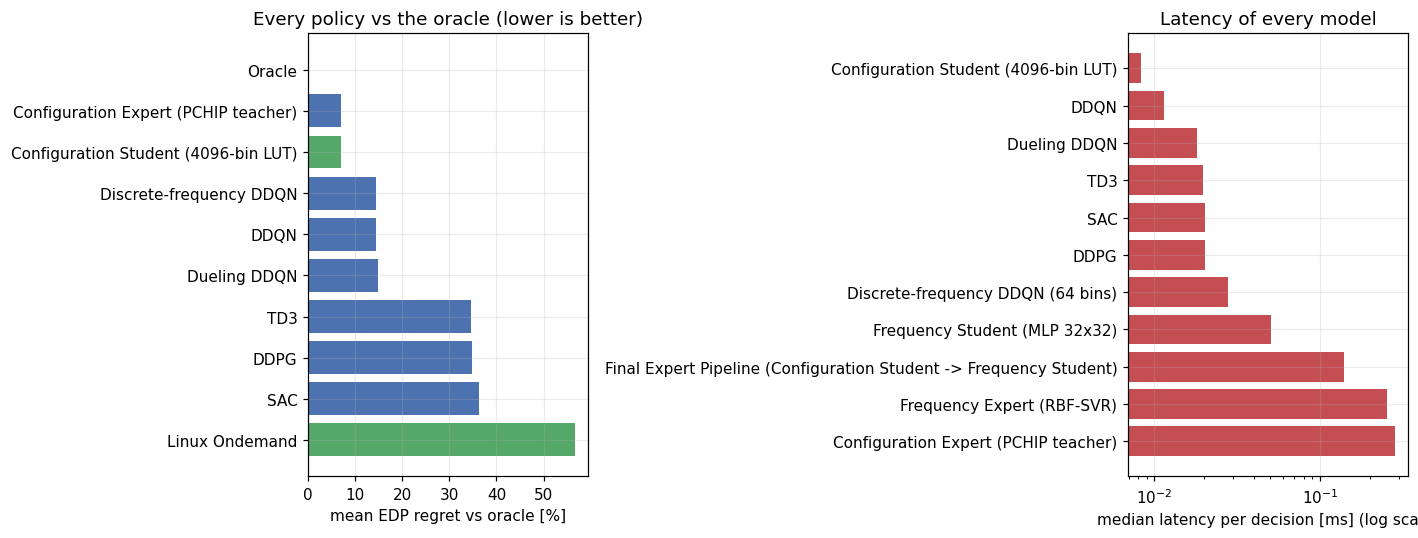

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
order = MASTER_TABLE.sort_values("mean_regret")
colors = ["#4C72B0" if p not in (FINAL_EXPERT_POLICY, "Oracle", "Linux Ondemand") else "#55A868"
          for p in order["policy"]]
ax.barh(order["policy"], 100 * order["mean_regret"], color=colors)
ax.set_xlabel("mean EDP regret vs oracle [%]")
ax.set_title("Every policy vs the oracle (lower is better)")
ax.invert_yaxis()

ax = axes[1]
lat = ALL_LATENCY.sort_values("median_ms")
ax.barh(lat["model"], lat["median_ms"], color="#C44E52")
ax.set_xscale("log")
ax.set_xlabel("median latency per decision [ms] (log scale)")
ax.set_title("Latency of every model")
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(RESULTS / "03_master_comparison.png", dpi=150)
plt.show()